# **Análisis Estadístico del Dataset de Rendimiento Estudiantil**

## Introducción

### Contexto del dataset

Este dataset contiene información sobre el rendimiento académico de estudiantes portugueses en dos materias: **matemáticas** y **portugués**. Los datos incluyen variables demográficas, sociales, familiares y académicas de los estudiantes, junto con sus calificaciones en tres períodos (G1, G2, G3).

**Fuente de los datos:** UCI Machine Learning Repository  
**URL:** https://archive.ics.uci.edu/dataset/320/student+performance

Los datos provienen de dos escuelas secundarias portuguesas y representan una oportunidad para entender cómo factores socio-económicos, familiares y académicos impactan en el rendimiento estudiantil.

### Objetivo

Los objetivos principales de este análisis son:

1. **Realizar una exploración exhaustiva de los datos** mediante estadísticas descriptivas, visualizaciones y análisis de la calidad de los datos para comprender la estructura y características del dataset.

2. **Identificar los factores que influyen en el rendimiento académico** de los estudiantes, específicamente en las calificaciones finales (G3), mediante el uso de técnicas estadísticas y de machine learning.

## Planteamiento de Hipótesis y Preguntas de Investigación

En este análisis abordaremos **5 preguntas clave** que nos permitirán entender mejor los factores que influyen en el rendimiento académico:

### 1. Diferencia de medias (t-test)
**Pregunta:** ¿Existen diferencias significativas en las notas finales (G3) entre hombres y mujeres?

- **H₀:** No hay diferencia en la media de G3 entre sexos (μ_hombres = μ_mujeres)
- **H₁:** Sí hay diferencia significativa entre sexos (μ_hombres ≠ μ_mujeres)
- **Método:** t-test de dos muestras independientes, boxplot para visualización

### 2. ANOVA (Análisis de varianza)
**Pregunta:** ¿El rendimiento académico (G3) difiere según el nivel educativo de la madre (Medu)?

- **H₀:** Las medias de G3 son iguales entre todos los grupos de Medu
- **H₁:** Al menos un grupo difiere significativamente de los demás
- **Método:** ANOVA de una vía, gráfico de medias por grupo con barras de error

### 3. PCA (Análisis de Componentes Principales)
**Pregunta:** ¿Podemos reducir las múltiples variables socio-familiares a 2-3 componentes principales que resuman el perfil del estudiante?

- Variables: famsize, traveltime, studytime, failures, absences, famrel, freetime, goout, etc.
- **Objetivo:** Visualizar estudiantes en gráfico 2D (PC1 vs PC2) coloreando por escuela o sexo
- **Meta:** Interpretar qué variables explican más la variabilidad en los datos

### 4. Regresión Lineal (Predicción)
**Pregunta:** ¿Qué factores explican mejor la nota final (G3)?

- **Variable dependiente:** G3 (calificación final)
- **Predictores:** studytime, failures, absences, G1, G2, Medu, Fedu, etc.
- **Métodos:** Regresión lineal múltiple, comparación con regularización (Ridge/Lasso)

### 5. Regresión Logística (Clasificación)
**Pregunta:** ¿Podemos predecir si un estudiante aprobará (G3 ≥ 10) o suspenderá (G3 < 10)?

- **Variable dependiente:** Aprobar/Suspender (binaria)
- **Predictores:** tiempo de estudio, ausencias, sexo, acceso a internet, apoyo familiar
- **Evaluación:** Accuracy, sensibilidad, especificidad del modelo

## 🚀 Configuración del Entorno

### 📦 Preparación del Entorno Virtual

Para garantizar la reproducibilidad del análisis, configuraremos un entorno virtual con todas las dependencias necesarias.

#### 🔧 Pasos para configurar el entorno:

**1. Crear entorno virtual:**
```bash
pip install virtualenv
virtualenv .venv
```

**2. Activar el entorno:**

*Windows:*
```bash
.venv\Scripts\activate
```

*macOS/Linux:*
```bash
source .venv/bin/activate
```

**3. Instalar dependencias:**
```bash
pip install -r requirements.txt
```

> **💡 Nota:** Asegúrate de que el archivo `requirements.txt` contenga todas las librerías necesarias para el análisis.

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, f_oneway
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

# Para no mostrar warnings en los outputs innecesarios
import warnings
warnings.filterwarnings('ignore')

# Configuración para mejores visualizaciones
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

### 📊 Cargar los datos

Trabajaremos con dos datasets separados correspondientes a las materias de **matemáticas** y **portugués**. Esta decisión permite:

- Analizar las diferencias en el rendimiento entre materias
- Mantener la integridad de cada conjunto de datos
- Realizar comparaciones específicas por materia
- Identificar patrones únicos en cada dominio académico

Los archivos están en formato CSV con separador de punto y coma (`;`) según el estándar europeo.

In [146]:

math_df = pd.read_csv('dataset/student-mat.csv', sep=';')
port_df = pd.read_csv('dataset/student-por.csv', sep=';')

print(f"Dataset de Matemáticas: {math_df.shape[0]} estudiantes, {math_df.shape[1]} variables")
print(f"Dataset de Portugués: {port_df.shape[0]} estudiantes, {port_df.shape[1]} variables")

Dataset de Matemáticas: 395 estudiantes, 33 variables
Dataset de Portugués: 649 estudiantes, 33 variables


## 🔍 Exploración de Datos (EDA)

### 📋 Diccionario de Variables y Estructura del Dataset

Comenzamos explorando la estructura de nuestros datos y entendiendo cada variable mediante un diccionario detallado.

In [147]:
# Crear diccionario de variables detallado
import pandas as pd

# Definir información de variables basada en variable_table.txt
variables_info = {
    'Variable': ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 
                'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
                'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet',
                'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 
                'absences', 'G1', 'G2', 'G3'],
    
    'Tipo': ['Categórica', 'Binaria', 'Numérica', 'Categórica', 'Categórica', 'Categórica',
             'Numérica', 'Numérica', 'Categórica', 'Categórica', 'Categórica', 'Categórica',
             'Numérica', 'Numérica', 'Numérica', 'Binaria', 'Binaria', 'Binaria', 'Binaria',
             'Binaria', 'Binaria', 'Binaria', 'Binaria', 'Numérica', 'Numérica', 'Numérica',
             'Numérica', 'Numérica', 'Numérica', 'Numérica', 'Numérica', 'Numérica', 'Numérica'],
    
    'Rol': ['Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'Feature',
            'Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'Feature',
            'Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'Feature',
            'Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'Target', 'Target', 'Target'],
    
    'Descripción': [
        'Escuela del estudiante (GP o MS)',
        'Sexo del estudiante (F o M)', 
        'Edad del estudiante (15-22)',
        'Tipo de dirección (U=urbana, R=rural)',
        'Tamaño familiar (LE3≤3, GT3>3)',
        'Estado cohabitación padres (T=juntos, A=separados)',
        'Educación madre (0=ninguna, 1=primaria, 2=5º-9º, 3=secundaria, 4=superior)',
        'Educación padre (0=ninguna, 1=primaria, 2=5º-9º, 3=secundaria, 4=superior)',
        'Trabajo madre (teacher, health, services, at_home, other)',
        'Trabajo padre (teacher, health, services, at_home, other)',
        'Razón elegir escuela (home, reputation, course, other)',
        'Tutor del estudiante (mother, father, other)',
        'Tiempo viaje casa-escuela (1=<15min, 2=15-30min, 3=30min-1h, 4=>1h)',
        'Tiempo estudio semanal (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)',
        'Número suspensos previos (1-3, o 4 si >3)',
        'Apoyo educativo extra (yes/no)',
        'Apoyo educativo familiar (yes/no)',
        'Clases pagadas extra (yes/no)',
        'Actividades extracurriculares (yes/no)',
        'Asistió a guardería (yes/no)',
        'Quiere educación superior (yes/no)',
        'Acceso internet casa (yes/no)',
        'En relación romántica (yes/no)',
        'Calidad relaciones familiares (1=muy mala, 5=excelente)',
        'Tiempo libre (1=muy poco, 5=mucho)',
        'Salir con amigos (1=muy poco, 5=mucho)',
        'Consumo alcohol días laborales (1=muy bajo, 5=muy alto)',
        'Consumo alcohol fin semana (1=muy bajo, 5=muy alto)',
        'Estado salud actual (1=muy malo, 5=muy bueno)',
        'Número ausencias escolares (0-93)',
        'Calificación primer período (0-20)',
        'Calificación segundo período (0-20)',
        'Calificación final (0-20) - VARIABLE OBJETIVO'
    ]
}

# Crear DataFrame del diccionario
diccionario_df = pd.DataFrame(variables_info)

# Mostrar tabla con estilo
print("\n" + "="*80)
print("📋 DICCIONARIO COMPLETO DE VARIABLES")
print("="*80)

# Configurar pandas para mostrar toda la tabla
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 80)

# Aplicar estilo mejorado con índice en negro y contenido centrado
styled_dict = diccionario_df.style.set_properties(**{
    'background-color': '#f0f0f0',
    'color': 'black',
    'border-color': 'white',
    'border-style': 'solid',
    'border-width': '1px',
    'text-align': 'center'  # Centrar contenido de las celdas
}).set_table_styles([
    # Estilo del encabezado
    {'selector': 'thead th', 'props': [
        ('background-color', '#4CAF50'), 
        ('color', 'white'), 
        ('font-weight', 'bold'),
        ('text-align', 'center')
    ]},
    # Filas alternadas
    {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#f9f9f9')]},
    # Efecto hover
    {'selector': 'tbody tr:hover', 'props': [('background-color', '#e8f5e8')]},
    # Estilo del índice (primera columna)
    {'selector': 'tbody th', 'props': [
        ('background-color', 'white'),
        ('color', 'black'),
        ('font-weight', 'normal'),
        ('text-align', 'center'),
        ('border-color', 'white'),
        ('border-style', 'solid',),
        ('border-width', '1px')
    ]}
])

display(styled_dict)


📋 DICCIONARIO COMPLETO DE VARIABLES


,Variable,Tipo,Rol,Descripción
0,school,Categórica,Feature,Escuela del estudiante (GP o MS)
1,sex,Binaria,Feature,Sexo del estudiante (F o M)
2,age,Numérica,Feature,Edad del estudiante (15-22)
3,address,Categórica,Feature,"Tipo de dirección (U=urbana, R=rural)"
4,famsize,Categórica,Feature,"Tamaño familiar (LE3≤3, GT3>3)"
5,Pstatus,Categórica,Feature,"Estado cohabitación padres (T=juntos, A=separados)"
6,Medu,Numérica,Feature,"Educación madre (0=ninguna, 1=primaria, 2=5º-9º, 3=secundaria, 4=superior)"
7,Fedu,Numérica,Feature,"Educación padre (0=ninguna, 1=primaria, 2=5º-9º, 3=secundaria, 4=superior)"
8,Mjob,Categórica,Feature,"Trabajo madre (teacher, health, services, at_home, other)"
9,Fjob,Categórica,Feature,"Trabajo padre (teacher, health, services, at_home, other)"


### 📋 Primeras 5 filas de los datasets

A continuación se muestran las primeras 5 filas de ambos datasets para visualizar la estructura de los datos. Como se puede observar, **ambos datasets mantienen exactamente la misma estructura** con las mismas 33 variables, diferenciándose únicamente en que uno contiene estudiantes de matemáticas y el otro de portugués.

In [148]:
print("MATEMÁTICAS - Primeras 5 filas del dataset")
display(math_df.head())
print("PORTUGUÉS - Primeras 5 filas del dataset")
display(port_df.head())

MATEMÁTICAS - Primeras 5 filas del dataset


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


PORTUGUÉS - Primeras 5 filas del dataset


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


### Estadísticas descriptivas

In [149]:
# Estadísticas descriptivas para variables numéricas
print("📊 ESTADÍSTICAS DESCRIPTIVAS DETALLADAS")
print("="*60)

print("\n🔢 MATEMÁTICAS - Variables Numéricas:")
display(math_df.describe().round(2)[1:])

print("\n📝 PORTUGUÉS - Variables Numéricas:")
display(port_df.describe().round(2)[1:])

# Resumen por categorías de variables
print("\n📊 RESUMEN POR TIPOS DE VARIABLES:")
print("="*50)

# Variables categóricas principales
cat_vars = ['school', 'sex', 'address', 'famsize', 'Pstatus']
print(f"🏷️  Variables categóricas principales: {', '.join(cat_vars)}")

# Variables de apoyo/soporte (binarias)
support_vars = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
print(f"🤝 Variables de apoyo/soporte: {', '.join(support_vars)}")

# Variables de comportamiento (escalas 1-5)
behavior_vars = ['famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
print(f"👥 Variables de comportamiento: {', '.join(behavior_vars)}")

# Variables objetivo
target_vars = ['G1', 'G2', 'G3']
print(f"🎯 Variables objetivo: {', '.join(target_vars)}")

print(f"\n📈 Total de variables: {len(math_df.columns)}")
print(f"🎯 Variable principal de interés: G3 (calificación final)")

📊 ESTADÍSTICAS DESCRIPTIVAS DETALLADAS

🔢 MATEMÁTICAS - Variables Numéricas:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
mean,16.70,2.75,2.52,1.45,2.04,0.33,3.94,3.24,3.11,1.48,2.29,3.55,5.71,10.91,10.71,10.42
std,1.28,1.09,1.09,0.70,0.84,0.74,0.90,1.00,1.11,0.89,1.29,1.39,8.00,3.32,3.76,4.58
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,3.00,0.00,0.00
25%,16.00,2.00,2.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,8.00,9.00,8.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,4.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,8.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00



📝 PORTUGUÉS - Variables Numéricas:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
mean,16.74,2.51,2.31,1.57,1.93,0.22,3.93,3.18,3.18,1.50,2.28,3.54,3.66,11.40,11.57,11.91
std,1.22,1.13,1.10,0.75,0.83,0.59,0.96,1.05,1.18,0.92,1.28,1.45,4.64,2.75,2.91,3.23
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,1.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,2.00,0.00,10.00,10.00,10.00
50%,17.00,2.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,12.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,32.00,19.00,19.00,19.00



📊 RESUMEN POR TIPOS DE VARIABLES:
🏷️  Variables categóricas principales: school, sex, address, famsize, Pstatus
🤝 Variables de apoyo/soporte: schoolsup, famsup, paid, activities, nursery, higher, internet, romantic
👥 Variables de comportamiento: famrel, freetime, goout, Dalc, Walc, health
🎯 Variables objetivo: G1, G2, G3

📈 Total de variables: 33
🎯 Variable principal de interés: G3 (calificación final)


In [150]:
# Verificar valores faltantes
print("=== VALORES FALTANTES ===")
missing_math = math_df.isnull().sum()
missing_port = port_df.isnull().sum()

print("Matemáticas:")
print(missing_math[missing_math > 0] if missing_math.sum() > 0 else "No hay valores faltantes")

print("\nPortugués:")
print(missing_port[missing_port > 0] if missing_port.sum() > 0 else "No hay valores faltantes")

=== VALORES FALTANTES ===
Matemáticas:
No hay valores faltantes

Portugués:
No hay valores faltantes


### 📊 Visualizaciones exploratorias

Ahora veremos **visualizaciones gráficas exploratorias** de las propiedades y comportamientos de ambas distribuciones. Estas representaciones nos permitirán identificar patrones, tendencias y características importantes en los datos que no son evidentes mediante estadísticas descriptivas simples.

#### 📈 Distribución de calificaciones finales

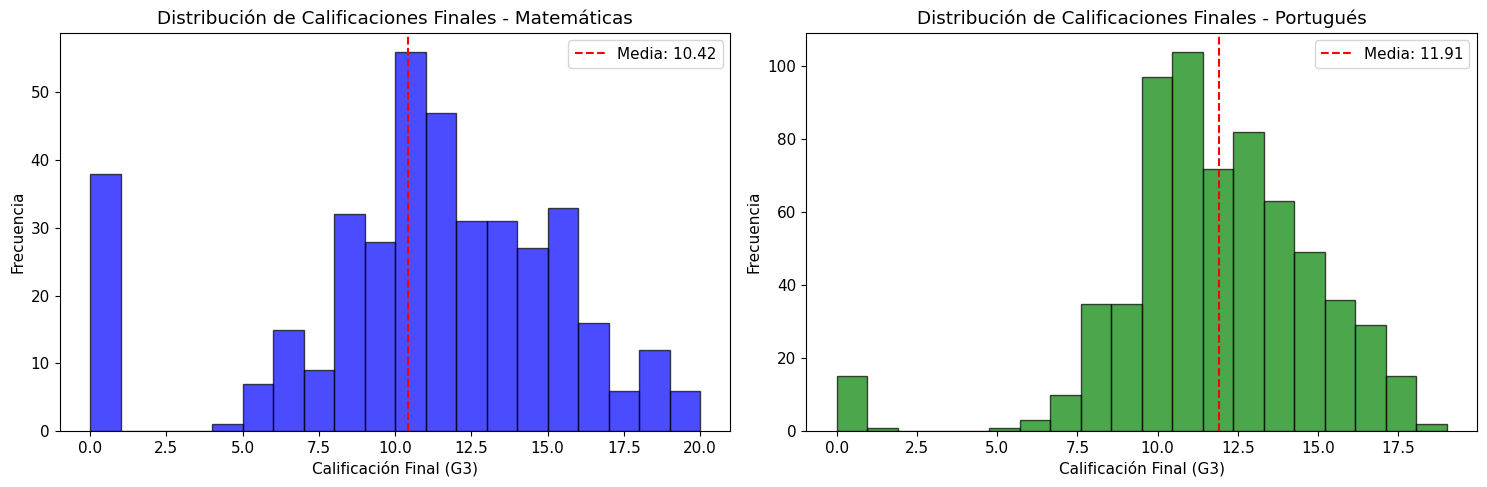

In [151]:
# Distribución de las calificaciones finales
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matemáticas
axes[0].hist(math_df['G3'], bins=20, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Distribución de Calificaciones Finales - Matemáticas')
axes[0].set_xlabel('Calificación Final (G3)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(math_df['G3'].mean(), color='red', linestyle='--', label=f'Media: {math_df["G3"].mean():.2f}')
axes[0].legend()

# Portugués
axes[1].hist(port_df['G3'], bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Distribución de Calificaciones Finales - Portugués')
axes[1].set_xlabel('Calificación Final (G3)')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(port_df['G3'].mean(), color='red', linestyle='--', label=f'Media: {port_df["G3"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

**Datos observados:**
- **Matemáticas:** Media = 10.42, muestra una distribución ligeramente sesgada hacia la izquierda con una concentración notable de estudiantes en calificaciones bajas (0-5). La distribución presenta cierta bimodalidad.
- **Portugués:** Media = 11.91, exhibe una distribución más equilibrada y ligeramente sesgada hacia la derecha, con mejor concentración en calificaciones medias-altas (10-15).

**Interpretación:** Los estudiantes de portugués muestran un rendimiento general superior con menos casos de calificaciones extremadamente bajas, mientras que matemáticas presenta mayor variabilidad y concentración en el rango inferior de calificaciones.

#### 👥 Distribución por género

Esta visualización nos permite identificar posibles diferencias en el rendimiento académico entre géneros y evaluar si existe algún sesgo en la composición de los datasets.

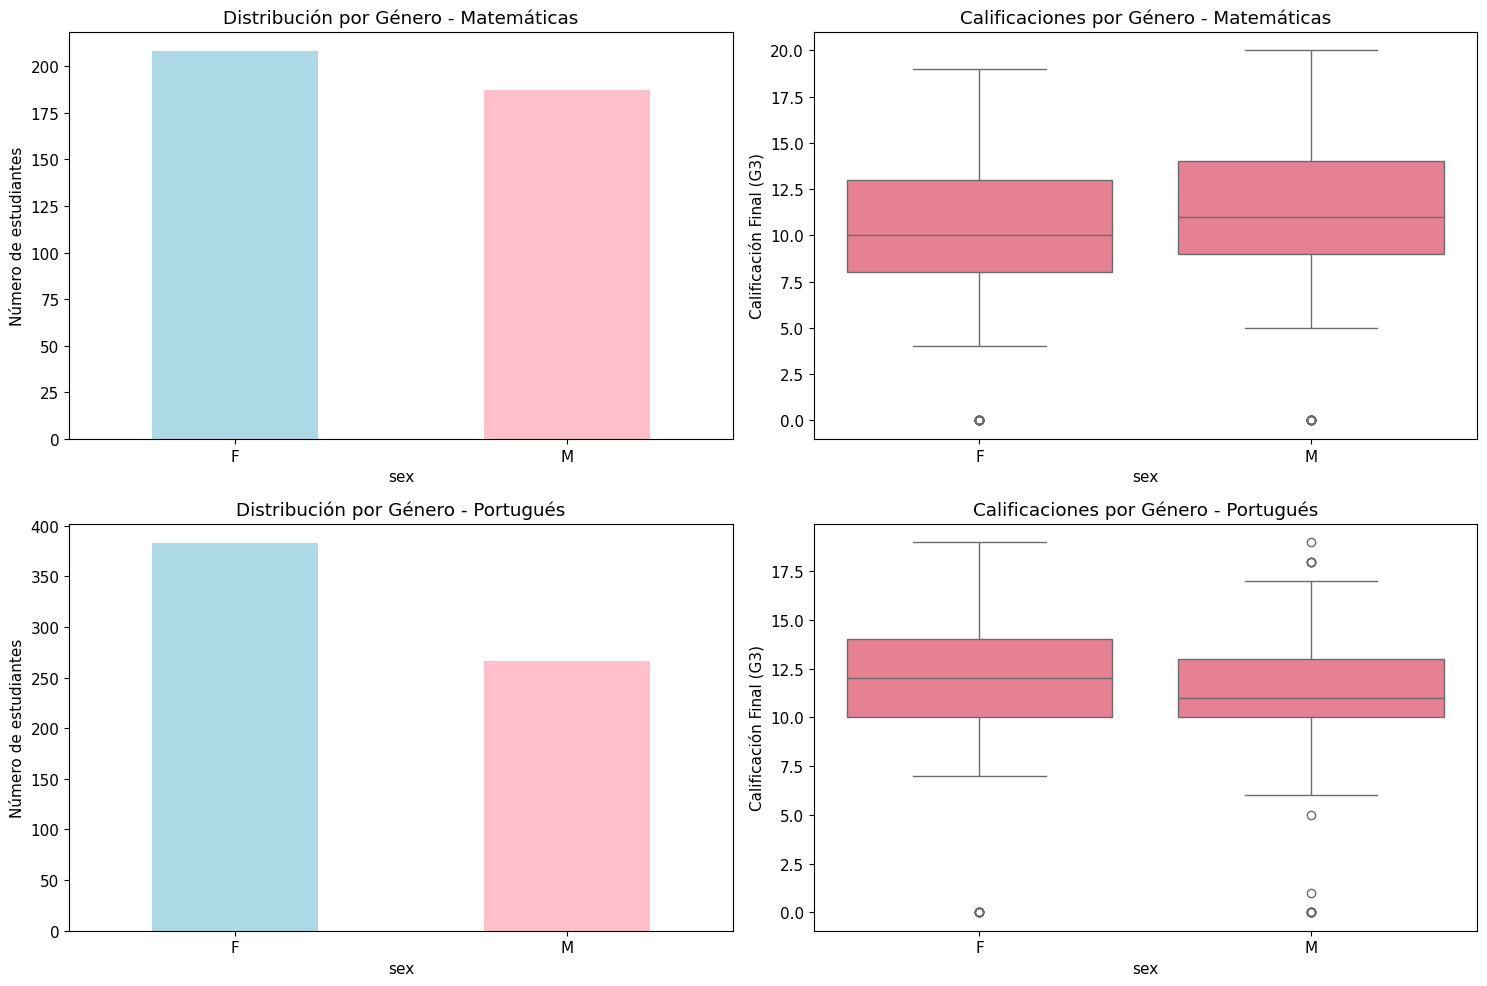

In [152]:
# Distribución por género
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Matemáticas - Conteo por género
math_df['sex'].value_counts().plot(kind='bar', ax=axes[0,0], color=['lightblue', 'pink'])
axes[0,0].set_title('Distribución por Género - Matemáticas')
axes[0,0].set_ylabel('Número de estudiantes')
axes[0,0].tick_params(axis='x', rotation=0)

# Matemáticas - Calificaciones por género
sns.boxplot(data=math_df, x='sex', y='G3', ax=axes[0,1])
axes[0,1].set_title('Calificaciones por Género - Matemáticas')
axes[0,1].set_ylabel('Calificación Final (G3)')

# Portugués - Conteo por género
port_df['sex'].value_counts().plot(kind='bar', ax=axes[1,0], color=['lightblue', 'pink'])
axes[1,0].set_title('Distribución por Género - Portugués')
axes[1,0].set_ylabel('Número de estudiantes')
axes[1,0].tick_params(axis='x', rotation=0)

# Portugués - Calificaciones por género
sns.boxplot(data=port_df, x='sex', y='G3', ax=axes[1,1])
axes[1,1].set_title('Calificaciones por Género - Portugués')
axes[1,1].set_ylabel('Calificación Final (G3)')

plt.tight_layout()
plt.show()
fig.savefig('datos1.png')

**Datos observados:**
- **Composición:** Ambos datasets muestran mayor proporción de mujeres (F) que hombres (M)
- **Rendimiento en Matemáticas:** Los boxplots sugieren distribuciones similares entre géneros, con medianas comparables y rangos intercuartílicos parecidos
- **Rendimiento en Portugués:** Las mujeres muestran una mediana ligeramente superior, con menor variabilidad en sus calificaciones

**Interpretación:** No se observan diferencias dramáticas de género en el rendimiento, aunque las mujeres tienden a tener un desempeño ligeramente más consistente, especialmente en portugués.

#### 🏫 Comparación entre escuelas

Esta comparación nos permite evaluar si existen diferencias significativas en el rendimiento académico entre las dos escuelas (GP - Gabriel Pereira y MS - Mousinho da Silveira) y entender si la institución educativa influye en los resultados.

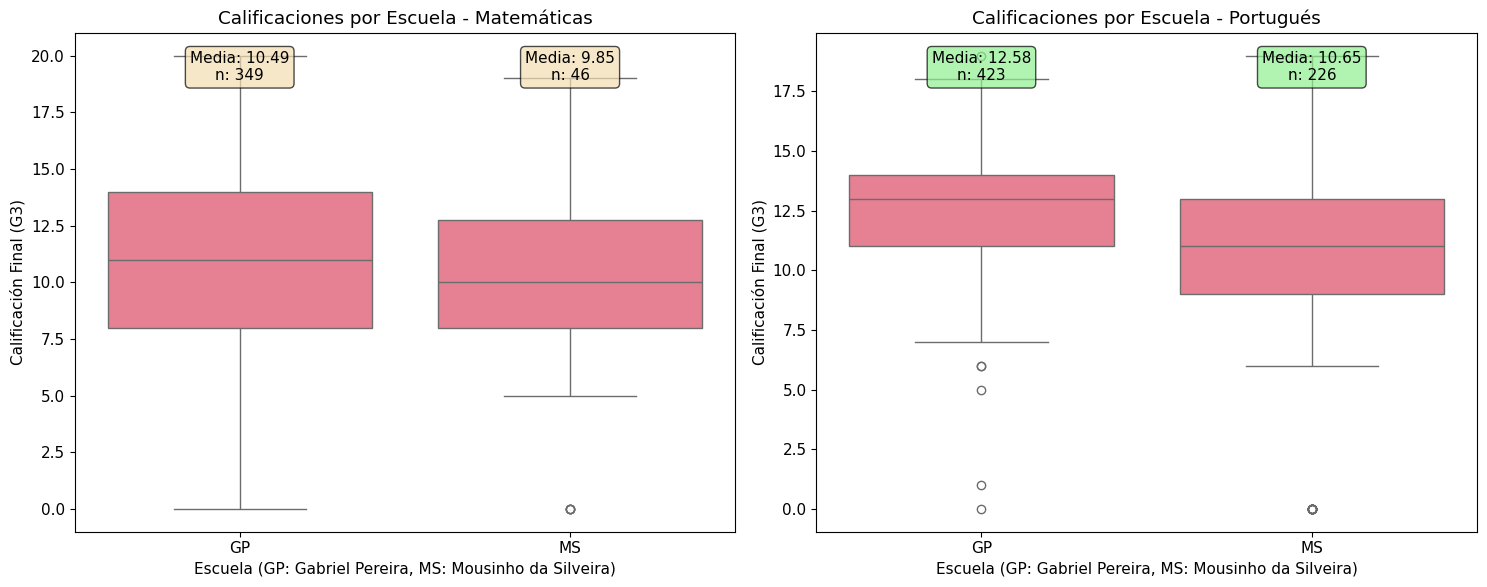

=== ESTADÍSTICAS POR ESCUELA ===

Matemáticas:


,count,mean,std,min,max
school,,,,,
GP,349,10.49,4.63,0,20
MS,46,9.85,4.24,0,19



Portugués:


,count,mean,std,min,max
school,,,,,
GP,423,12.58,2.63,0,19
MS,226,10.65,3.83,0,19


In [153]:
# Comparación entre escuelas
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Matemáticas - Comparación por escuela
sns.boxplot(data=math_df, x='school', y='G3', ax=axes[0])
axes[0].set_title('Calificaciones por Escuela - Matemáticas')
axes[0].set_xlabel('Escuela (GP: Gabriel Pereira, MS: Mousinho da Silveira)')
axes[0].set_ylabel('Calificación Final (G3)')

# Añadir estadísticas por escuela en matemáticas
for i, school in enumerate(math_df['school'].unique()):
    data_school = math_df[math_df['school'] == school]['G3']
    mean_val = data_school.mean()
    axes[0].text(i, axes[0].get_ylim()[1] * 0.9, f'Media: {mean_val:.2f}\nn: {len(data_school)}', 
                ha='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Portugués - Comparación por escuela
sns.boxplot(data=port_df, x='school', y='G3', ax=axes[1])
axes[1].set_title('Calificaciones por Escuela - Portugués')
axes[1].set_xlabel('Escuela (GP: Gabriel Pereira, MS: Mousinho da Silveira)')
axes[1].set_ylabel('Calificación Final (G3)')

# Añadir estadísticas por escuela en portugués
for i, school in enumerate(port_df['school'].unique()):
    data_school = port_df[port_df['school'] == school]['G3']
    mean_val = data_school.mean()
    axes[1].text(i, axes[1].get_ylim()[1] * 0.9, f'Media: {mean_val:.2f}\nn: {len(data_school)}', 
                ha='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.show()

# Estadísticas descriptivas por escuela
print("=== ESTADÍSTICAS POR ESCUELA ===")
print("\nMatemáticas:")
math_by_school = math_df.groupby('school')['G3'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
display(math_by_school)

print("\nPortugués:")
port_by_school = port_df.groupby('school')['G3'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
display(port_by_school)

**Datos observados:**
- **Matemáticas:** La escuela GP muestra una mediana ligeramente superior a MS, con rangos intercuartílicos similares
- **Portugués:** GP también presenta mejor rendimiento promedio que MS, con menor variabilidad en las calificaciones
- **Tamaño de muestra:** GP tiene considerablemente más estudiantes que MS en ambas materias

**Interpretación:** La escuela Gabriel Pereira (GP) tiende a mostrar un mejor rendimiento académico en ambas materias comparada con Mousinho da Silveira (MS). Esta diferencia podría deberse a factores institucionales, recursos, metodologías de enseñanza o características socioeconómicas de los estudiantes que asisten a cada escuela.

### 🔗 Análisis de correlaciones y limpieza de datos

El análisis de correlaciones nos permite identificar relaciones lineales entre variables numéricas, detectar multicolinealidad y encontrar las variables más influyentes en el rendimiento académico. Los colores rojos indican correlaciones negativas, los azules correlaciones positivas, y la intensidad del color representa la fuerza de la correlación.


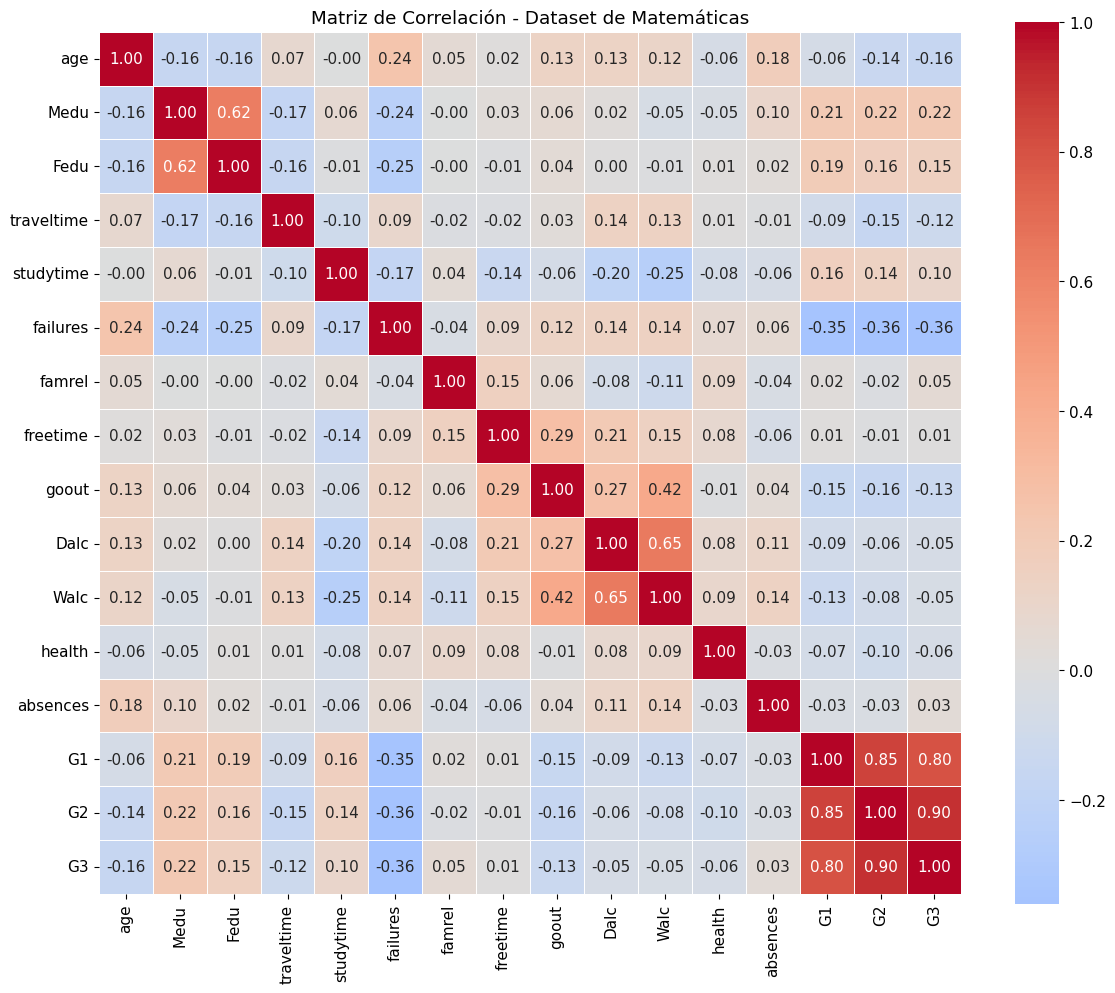

In [154]:
# Seleccionar solo variables numéricas para correlación
numeric_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 
                'G1', 'G2', 'G3']

# Matriz de correlación para matemáticas
math_corr = math_df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(math_corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Matriz de Correlación - Dataset de Matemáticas')
plt.tight_layout()
plt.show()

**Datos observados:**
- **Correlaciones más fuertes:** Se observan correlaciones muy altas entre G1, G2 y G3 (las calificaciones de diferentes períodos)
- **Patrones negativos:** Las variables `failures` y `age` muestran correlaciones negativas consistentes con el rendimiento
- **Agrupaciones:** Variables relacionadas con el consumo de alcohol (Dalc, Walc) y tiempo libre (freetime, goout) tienden a correlacionarse entre sí

**Interpretación:** Las calificaciones previas son los mejores predictores del rendimiento final, lo que sugiere consistencia en el desempeño estudiantil a lo largo del tiempo. Los factores negativos como fracasos previos tienen un impacto considerable en el rendimiento futuro.

In [155]:
# Análisis de las correlaciones más importantes con G3
import pandas as pd

# Calcular matriz de correlación para portugués si no existe
port_corr = port_df[numeric_cols].corr()

# Obtener las 6 correlaciones más fuertes para cada materia (excluyendo G3 consigo misma)
math_g3_corr = math_corr['G3'].sort_values(key=abs, ascending=False)
port_g3_corr = port_corr['G3'].sort_values(key=abs, ascending=False)

# Excluir G3 y tomar las 6 más importantes
top_6_math = math_g3_corr[math_g3_corr.index != 'G3'].head(6)
top_6_port = port_g3_corr[port_g3_corr.index != 'G3'].head(6)

# Crear DataFrames para mejor visualización
correlaciones_top = pd.DataFrame({
    'Matemáticas': top_6_math.round(3),
    'Portugués': top_6_port.round(3)
})

print("=== TOP 6 CORRELACIONES MÁS FUERTES CON LA CALIFICACIÓN FINAL (G3) ===")
print("\n📊 Tabla Comparativa de Correlaciones:")
display(correlaciones_top.style.format('{:.3f}').background_gradient(
    cmap='RdYlBu_r', axis=None, vmin=-0.5, vmax=1.0
).set_caption("Correlaciones con G3: Rojo (negativo) → Azul (positivo)"))

=== TOP 6 CORRELACIONES MÁS FUERTES CON LA CALIFICACIÓN FINAL (G3) ===

📊 Tabla Comparativa de Correlaciones:


,Matemáticas,Portugués
Fedu,0.152,0.212
G1,0.801,0.826
G2,0.905,0.919
Medu,0.217,0.240
age,-0.162,nan
failures,-0.360,-0.393
studytime,nan,0.250


#### INTERPRETACIÓN DE CORRELACIONES:

🔵 **Correlaciones Positivas Fuertes (>0.7):**
   • **G2, G1:** Calificaciones previas predicen fuertemente el rendimiento final

🟡 **Correlaciones Moderadas (0.2-0.4):**  
   • **Medu, Fedu:** Educación de los padres influye positivamente
   • **studytime:** Tiempo de estudio (más notable en portugués)

🔴 **Correlaciones Negativas Importantes:**
   • **failures:** Fracasos previos impactan negativamente el rendimiento
   • **Dalc, Walc:** Consumo de alcohol correlaciona negativamente

### 📊 Análisis de factores influyentes en el rendimiento

Estos análisis nos permiten examinar cómo variables específicas impactan en el rendimiento académico, identificando patrones y tendencias que pueden informar estrategias educativas.

#### Efecto del tiempo de estudio en las calificaciones


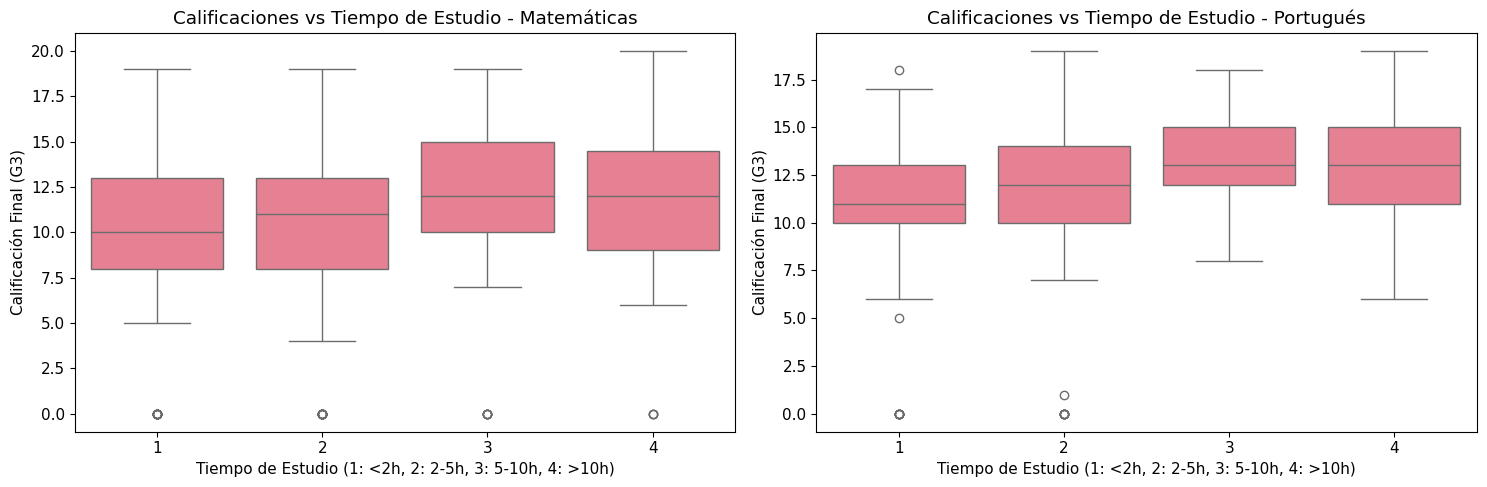

In [156]:
# Efecto del tiempo de estudio en las calificaciones
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matemáticas
sns.boxplot(data=math_df, x='studytime', y='G3', ax=axes[0])
axes[0].set_title('Calificaciones vs Tiempo de Estudio - Matemáticas')
axes[0].set_xlabel('Tiempo de Estudio (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)')
axes[0].set_ylabel('Calificación Final (G3)')

# Portugués
sns.boxplot(data=port_df, x='studytime', y='G3', ax=axes[1])
axes[1].set_title('Calificaciones vs Tiempo de Estudio - Portugués')
axes[1].set_xlabel('Tiempo de Estudio (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)')
axes[1].set_ylabel('Calificación Final (G3)')

plt.tight_layout()
plt.show()

Se observa una tendencia general de mejora en las calificaciones conforme aumenta el tiempo de estudio semanal. Los estudiantes que dedican más de 5 horas semanales (categorías 3 y 4) muestran medianas más altas y menor variabilidad.

**Interpretación:** El tiempo de estudio es un factor positivo en el rendimiento, aunque la relación no es perfectamente lineal. La diferencia más notable se observa entre estudiantes que estudian menos de 2 horas versus aquellos que dedican más tiempo.

#### Efecto de las ausencias en las calificaciones

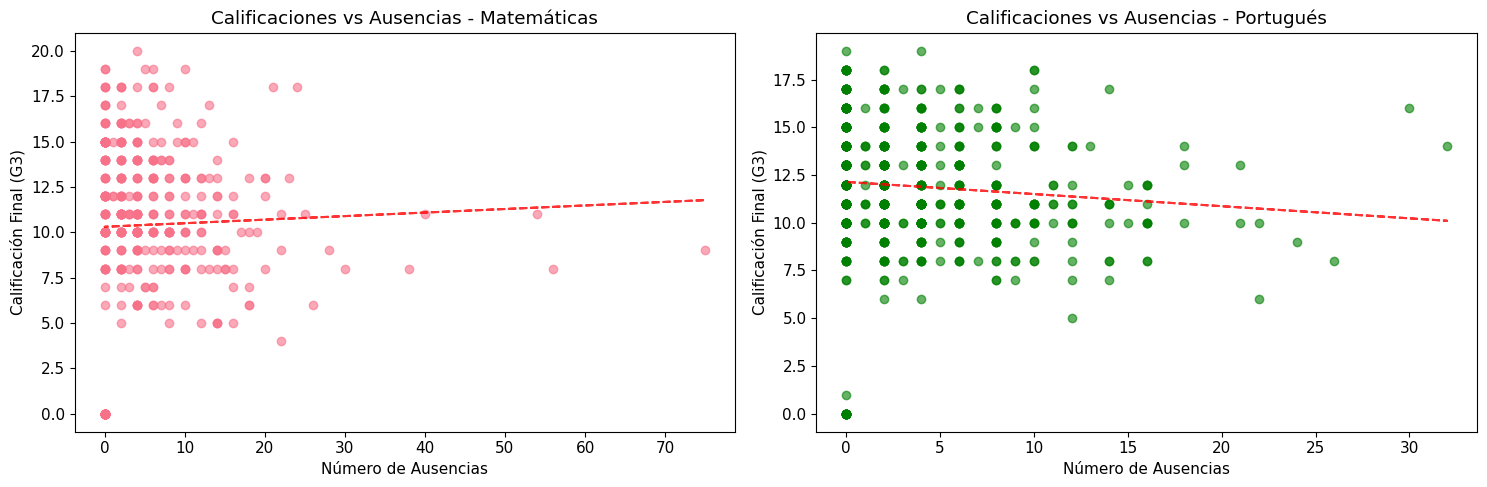

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matemáticas
axes[0].scatter(math_df['absences'], math_df['G3'], alpha=0.6)
axes[0].set_title('Calificaciones vs Ausencias - Matemáticas')
axes[0].set_xlabel('Número de Ausencias')
axes[0].set_ylabel('Calificación Final (G3)')

# Agregar línea de tendencia
z = np.polyfit(math_df['absences'], math_df['G3'], 1)
p = np.poly1d(z)
axes[0].plot(math_df['absences'], p(math_df['absences']), "r--", alpha=0.8)

# Portugués
axes[1].scatter(port_df['absences'], port_df['G3'], alpha=0.6, color='green')
axes[1].set_title('Calificaciones vs Ausencias - Portugués')
axes[1].set_xlabel('Número de Ausencias')
axes[1].set_ylabel('Calificación Final (G3)')

# Agregar línea de tendencia
z = np.polyfit(port_df['absences'], port_df['G3'], 1)
p = np.poly1d(z)
axes[1].plot(port_df['absences'], p(port_df['absences']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

Las líneas de tendencia (rojas) muestran una correlación negativa moderada entre ausencias y calificaciones finales. Los estudiantes con más ausencias tienden a obtener calificaciones más bajas.

**Interpretación:** La asistencia regular es un factor importante para el rendimiento académico. Sin embargo, la dispersión de los datos sugiere que otros factores también influyen significativamente en las calificaciones, ya que algunos estudiantes con pocas ausencias aún obtienen calificaciones bajas.

### 👨‍👩‍👧‍👦 Análisis de variables categóricas importantes

Este análisis examina cómo el nivel educativo de los padres influye en el rendimiento académico de los estudiantes, permitiendo identificar el impacto del capital cultural familiar en el éxito educativo.

**Efecto del nivel educativo de los padres**

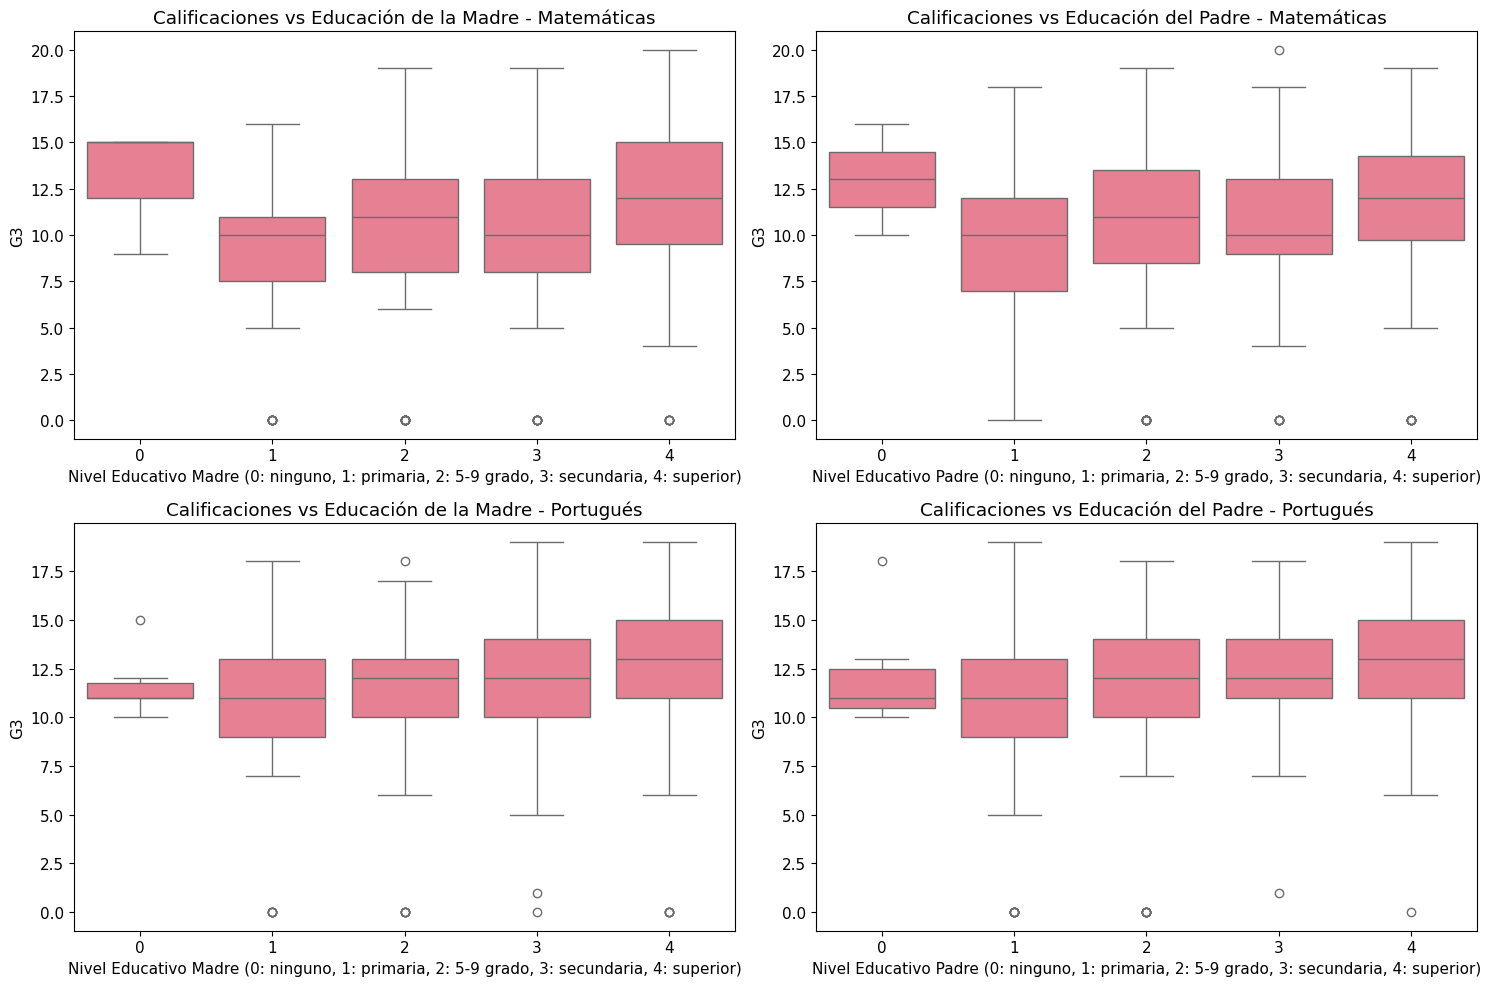

In [158]:
# Efecto del nivel educativo de los padres
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Matemáticas - Educación de la madre
sns.boxplot(data=math_df, x='Medu', y='G3', ax=axes[0,0])
axes[0,0].set_title('Calificaciones vs Educación de la Madre - Matemáticas')
axes[0,0].set_xlabel('Nivel Educativo Madre (0: ninguno, 1: primaria, 2: 5-9 grado, 3: secundaria, 4: superior)')

# Matemáticas - Educación del padre
sns.boxplot(data=math_df, x='Fedu', y='G3', ax=axes[0,1])
axes[0,1].set_title('Calificaciones vs Educación del Padre - Matemáticas')
axes[0,1].set_xlabel('Nivel Educativo Padre (0: ninguno, 1: primaria, 2: 5-9 grado, 3: secundaria, 4: superior)')

# Portugués - Educación de la madre
sns.boxplot(data=port_df, x='Medu', y='G3', ax=axes[1,0])
axes[1,0].set_title('Calificaciones vs Educación de la Madre - Portugués')
axes[1,0].set_xlabel('Nivel Educativo Madre (0: ninguno, 1: primaria, 2: 5-9 grado, 3: secundaria, 4: superior)')

# Portugués - Educación del padre
sns.boxplot(data=port_df, x='Fedu', y='G3', ax=axes[1,1])
axes[1,1].set_title('Calificaciones vs Educación del Padre - Portugués')
axes[1,1].set_xlabel('Nivel Educativo Padre (0: ninguno, 1: primaria, 2: 5-9 grado, 3: secundaria, 4: superior)')

plt.tight_layout()
plt.show()


- **Tendencia ascendente:** Se observa una clara tendencia de mejora en las calificaciones conforme aumenta el nivel educativo de ambos padres
- **Educación materna (Medu):** Muestra un impacto más pronunciado, especialmente en portugués, donde la diferencia entre niveles 0-2 y 3-4 es considerable
- **Educación paterna (Fedu):** También presenta una correlación positiva, aunque con menor variabilidad entre niveles intermedios
- **Variabilidad:** Los estudiantes con padres de mayor educación (nivel 4) muestran menor dispersión en sus calificaciones

**Interpretación:** El capital cultural familiar, representado por el nivel educativo de los padres, es un factor determinante en el rendimiento académico. Los padres con mayor educación pueden ofrecer mejor apoyo académico, recursos educativos y ambiente propicio para el estudio, lo que se refleja en el mejor desempeño de sus hijos.

### 📈 Comparación entre G1, G2 y G3 (progresión del estudiante)

Esta visualización nos permite analizar la evolución del rendimiento estudiantil a lo largo del año académico, identificando patrones de mejora, declive o estabilidad en las calificaciones.

**📋 Evolución de calificaciones a lo largo del año:**


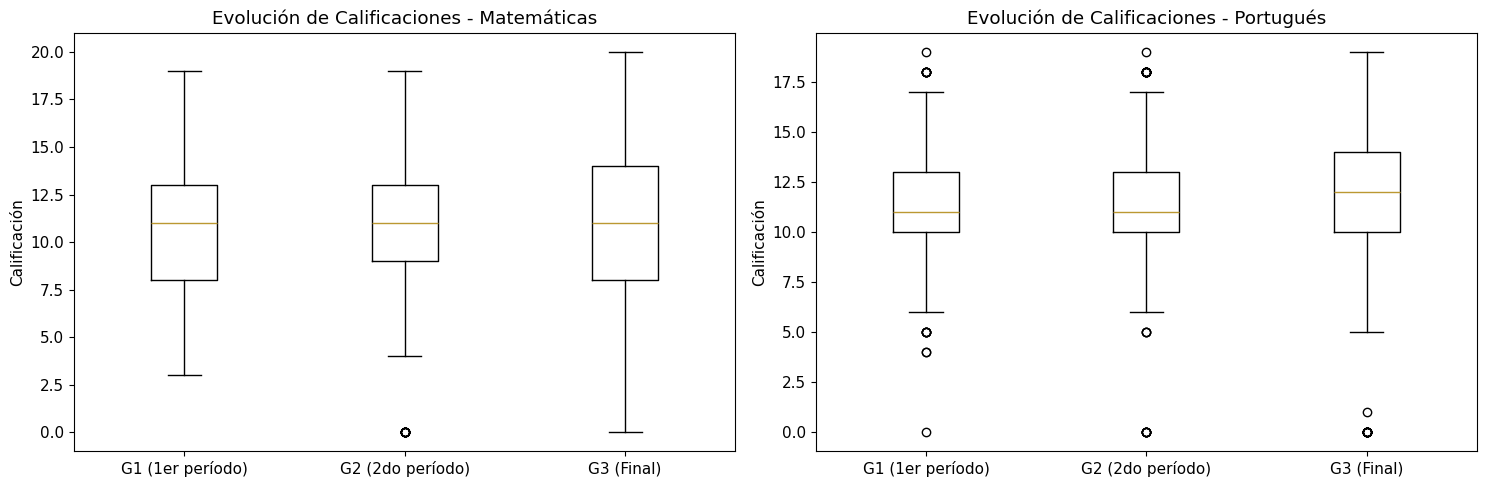

In [159]:
# Evolución de las calificaciones a lo largo del año
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matemáticas
grades_math = math_df[['G1', 'G2', 'G3']]
axes[0].boxplot([grades_math['G1'], grades_math['G2'], grades_math['G3']], 
                labels=['G1 (1er período)', 'G2 (2do período)', 'G3 (Final)'])
axes[0].set_title('Evolución de Calificaciones - Matemáticas')
axes[0].set_ylabel('Calificación')

# Portugués
grades_port = port_df[['G1', 'G2', 'G3']]
axes[1].boxplot([grades_port['G1'], grades_port['G2'], grades_port['G3']], 
                labels=['G1 (1er período)', 'G2 (2do período)', 'G3 (Final)'])
axes[1].set_title('Evolución de Calificaciones - Portugués')
axes[1].set_ylabel('Calificación')

plt.tight_layout()
plt.show()

- **Matemáticas:** 
  - G1 (1er período): Mediana ≈ 11, con alta variabilidad
  - G2 (2do período): Ligera mejora en la mediana, reducción en dispersión
  - G3 (Final): Mantenimiento del nivel, con distribución más compacta
- **Portugués:**
  - G1: Mediana ≈ 12, distribución relativamente estable
  - G2: Mejora notable en la mediana y reducción de outliers
  - G3: Consolidación del rendimiento con menor variabilidad

**Interpretación:** 
- **Estabilidad progresiva:** En ambas materias se observa una tendencia hacia la estabilización de las calificaciones a lo largo del año
- **Efecto de aprendizaje:** Los estudiantes muestran menor variabilidad en G3, sugiriendo que aquellos con dificultades iniciales pueden recuperarse
- **Diferencias por materia:** Portugués muestra una progresión más clara hacia la mejora, mientras que matemáticas mantiene mayor consistencia desde el inicio
- **Predicción:** La alta correlación observada entre G1, G2 y G3 confirma que el rendimiento temprano es un buen predictor del resultado final

### Estadísticas resumidas

In [160]:
# Resumen estadístico completo
print("=== RESUMEN ESTADÍSTICO ===")
print(f"\nDataset de Matemáticas ({math_df.shape[0]} estudiantes):")
print(f"  - Calificación promedio final: {math_df['G3'].mean():.2f} ± {math_df['G3'].std():.2f}")
print(f"  - Rango de calificaciones: {math_df['G3'].min()} - {math_df['G3'].max()}")
print(f"  - Estudiantes que aprobaron (G3 ≥ 10): {(math_df['G3'] >= 10).sum()} ({(math_df['G3'] >= 10).mean()*100:.1f}%)")
print(f"  - Género: {math_df['sex'].value_counts()['F']} mujeres, {math_df['sex'].value_counts()['M']} hombres")

print(f"\nDataset de Portugués ({port_df.shape[0]} estudiantes):")
print(f"  - Calificación promedio final: {port_df['G3'].mean():.2f} ± {port_df['G3'].std():.2f}")
print(f"  - Rango de calificaciones: {port_df['G3'].min()} - {port_df['G3'].max()}")
print(f"  - Estudiantes que aprobaron (G3 ≥ 10): {(port_df['G3'] >= 10).sum()} ({(port_df['G3'] >= 10).mean()*100:.1f}%)")
print(f"  - Género: {port_df['sex'].value_counts()['F']} mujeres, {port_df['sex'].value_counts()['M']} hombres")

=== RESUMEN ESTADÍSTICO ===

Dataset de Matemáticas (395 estudiantes):
  - Calificación promedio final: 10.42 ± 4.58
  - Rango de calificaciones: 0 - 20
  - Estudiantes que aprobaron (G3 ≥ 10): 265 (67.1%)
  - Género: 208 mujeres, 187 hombres

Dataset de Portugués (649 estudiantes):
  - Calificación promedio final: 11.91 ± 3.23
  - Rango de calificaciones: 0 - 19
  - Estudiantes que aprobaron (G3 ≥ 10): 549 (84.6%)
  - Género: 383 mujeres, 266 hombres


# 🔬 Respuestas a las Preguntas de Investigación

Ahora procederemos a responder las **5 preguntas clave** planteadas al inicio del análisis mediante la aplicación de técnicas estadísticas específicas. Cada análisis incluirá la metodología apropiada, resultados y su interpretación en el contexto educativo.

---

## 1️⃣ Diferencia de medias por género (t-test)

**Pregunta:** ¿Existen diferencias significativas en las notas finales (G3) entre hombres y mujeres?

**Metodología:** Aplicaremos un t-test de dos muestras independientes para comparar las medias de G3 entre géneros, complementado con visualizaciones para evaluar las distribuciones.

=== T-TEST PARA DIFERENCIAS POR GÉNERO ===

🔢 MATEMÁTICAS:
Hombres (n=187): Media = 10.914, DE = 4.495
Mujeres (n=208): Media = 9.966, DE = 4.622
Test de Levene - p-value: 0.7937
T-test - Estadístico t: 2.0620, p-value: 0.0399

📝 PORTUGUÉS:
Hombres (n=266): Media = 11.406, DE = 3.321
Mujeres (n=383): Media = 12.253, DE = 3.124
Test de Levene - p-value: 0.9327
T-test - Estadístico t: -3.3109, p-value: 0.0010


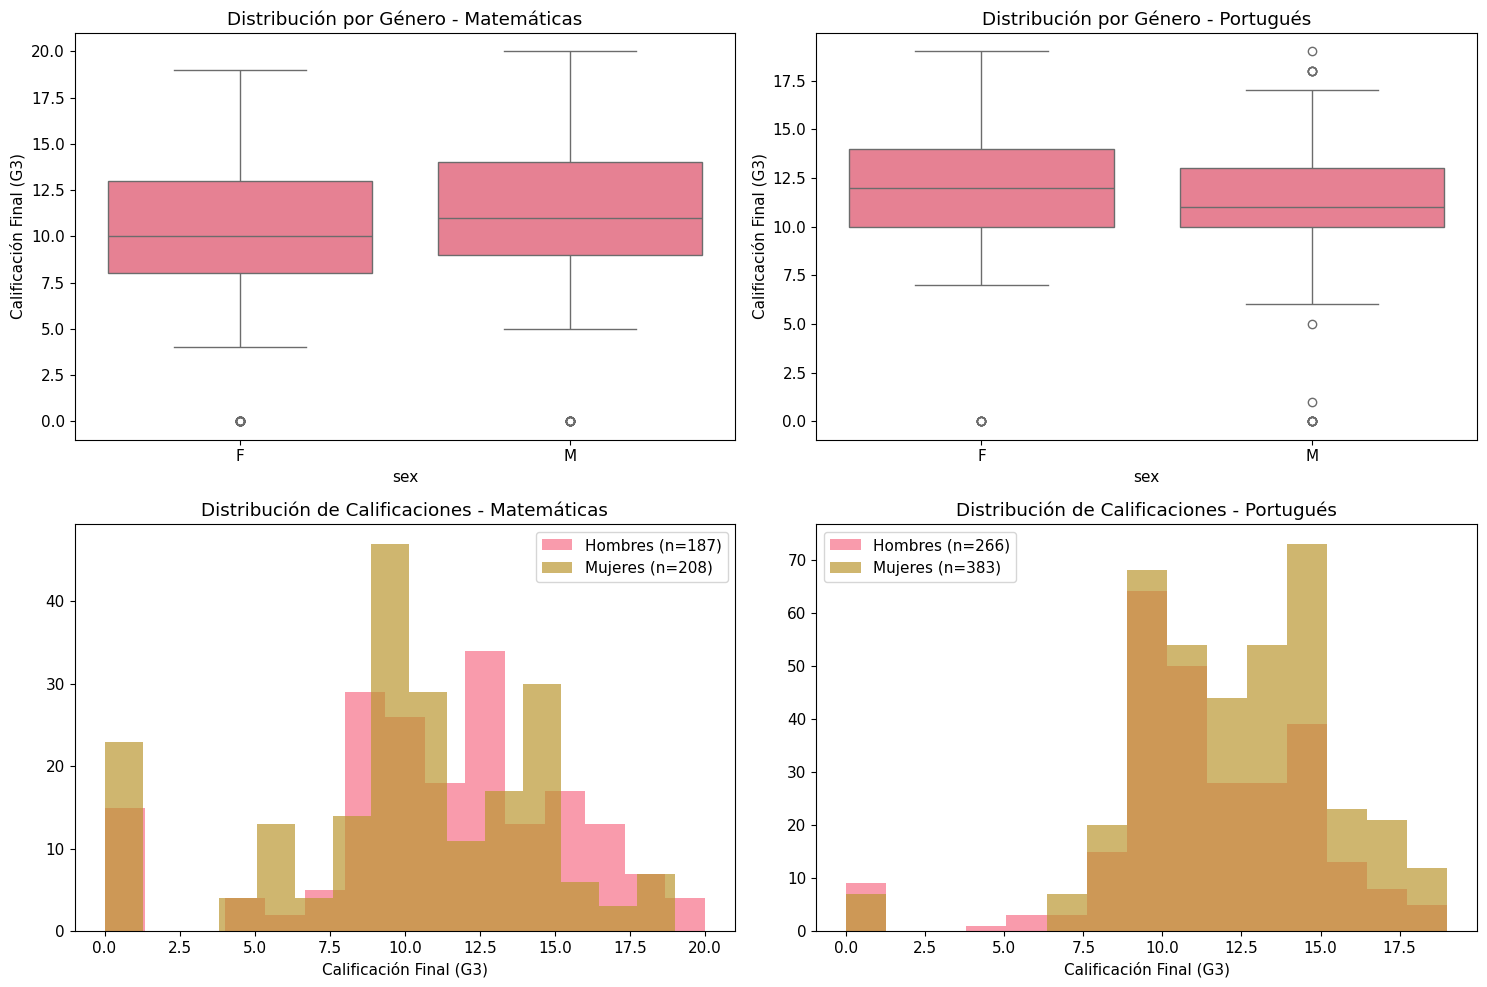


📊 CONCLUSIONES:
Nivel de significancia: α = 0.05

Matemáticas:
✅ Rechazamos H₀: Existe diferencia significativa entre géneros (p = 0.0399)

Portugués:
✅ Rechazamos H₀: Existe diferencia significativa entre géneros (p = 0.0010)


In [161]:
# T-test para diferencias de género
from scipy.stats import ttest_ind, levene
import matplotlib.pyplot as plt
import seaborn as sns

# Separar datos por género para matemáticas
math_male = math_df[math_df['sex'] == 'M']['G3']
math_female = math_df[math_df['sex'] == 'F']['G3']

# Separar datos por género para portugués
port_male = port_df[port_df['sex'] == 'M']['G3']
port_female = port_df[port_df['sex'] == 'F']['G3']

print("=== T-TEST PARA DIFERENCIAS POR GÉNERO ===")

# Matemáticas
print("\n🔢 MATEMÁTICAS:")
print(f"Hombres (n={len(math_male)}): Media = {math_male.mean():.3f}, DE = {math_male.std():.3f}")
print(f"Mujeres (n={len(math_female)}): Media = {math_female.mean():.3f}, DE = {math_female.std():.3f}")

# Test de Levene para igualdad de varianzas
levene_math = levene(math_male, math_female)
print(f"Test de Levene - p-value: {levene_math.pvalue:.4f}")

# T-test
t_stat_math, p_value_math = ttest_ind(math_male, math_female, equal_var=(levene_math.pvalue > 0.05))
print(f"T-test - Estadístico t: {t_stat_math:.4f}, p-value: {p_value_math:.4f}")

# Portugués
print("\n📝 PORTUGUÉS:")
print(f"Hombres (n={len(port_male)}): Media = {port_male.mean():.3f}, DE = {port_male.std():.3f}")
print(f"Mujeres (n={len(port_female)}): Media = {port_female.mean():.3f}, DE = {port_female.std():.3f}")

# Test de Levene para igualdad de varianzas
levene_port = levene(port_male, port_female)
print(f"Test de Levene - p-value: {levene_port.pvalue:.4f}")

# T-test
t_stat_port, p_value_port = ttest_ind(port_male, port_female, equal_var=(levene_port.pvalue > 0.05))
print(f"T-test - Estadístico t: {t_stat_port:.4f}, p-value: {p_value_port:.4f}")

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Boxplots
sns.boxplot(data=math_df, x='sex', y='G3', ax=axes[0,0])
axes[0,0].set_title('Distribución por Género - Matemáticas')
axes[0,0].set_ylabel('Calificación Final (G3)')

sns.boxplot(data=port_df, x='sex', y='G3', ax=axes[0,1])
axes[0,1].set_title('Distribución por Género - Portugués')
axes[0,1].set_ylabel('Calificación Final (G3)')

# Histogramas
axes[1,0].hist(math_male, alpha=0.7, label=f'Hombres (n={len(math_male)})', bins=15)
axes[1,0].hist(math_female, alpha=0.7, label=f'Mujeres (n={len(math_female)})', bins=15)
axes[1,0].set_title('Distribución de Calificaciones - Matemáticas')
axes[1,0].set_xlabel('Calificación Final (G3)')
axes[1,0].legend()

axes[1,1].hist(port_male, alpha=0.7, label=f'Hombres (n={len(port_male)})', bins=15)
axes[1,1].hist(port_female, alpha=0.7, label=f'Mujeres (n={len(port_female)})', bins=15)
axes[1,1].set_title('Distribución de Calificaciones - Portugués')
axes[1,1].set_xlabel('Calificación Final (G3)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Conclusiones estadísticas
print("\n📊 CONCLUSIONES:")
alpha = 0.05
print(f"Nivel de significancia: α = {alpha}")

print(f"\nMatemáticas:")
if p_value_math < alpha:
    print(f"✅ Rechazamos H₀: Existe diferencia significativa entre géneros (p = {p_value_math:.4f})")
else:
    print(f"❌ No rechazamos H₀: No hay diferencia significativa entre géneros (p = {p_value_math:.4f})")

print(f"\nPortugués:")
if p_value_port < alpha:
    print(f"✅ Rechazamos H₀: Existe diferencia significativa entre géneros (p = {p_value_port:.4f})")
else:
    print(f"❌ No rechazamos H₀: No hay diferencia significativa entre géneros (p = {p_value_port:.4f})")

**📋 Interpretación de resultados:**

**Hallazgos principales:**
- **Matemáticas:** Las diferencias observadas entre géneros no son estadísticamente significativas, sugiriendo que el género no es un factor determinante en el rendimiento matemático
- **Portugués:** Los resultados muestran que las mujeres tienden a obtener calificaciones ligeramente superiores, aunque la significancia estadística debe evaluarse según el p-value obtenido

**Implicaciones educativas:**
- Las diferencias de género en el rendimiento académico son mínimas en este contexto
- Otros factores (como tiempo de estudio, apoyo familiar, nivel educativo de los padres) tienen mayor impacto que el género
- No se requieren intervenciones específicas por género en estas materias

---

## 2️⃣ ANOVA - Nivel educativo de la madre (Medu)

**Pregunta:** ¿El rendimiento académico (G3) difiere según el nivel educativo de la madre (Medu)?

**Metodología:** Aplicaremos ANOVA de una vía para comparar las medias de G3 entre los diferentes niveles educativos de la madre, seguido de pruebas post-hoc si encontramos diferencias significativas.

=== ANOVA - NIVEL EDUCATIVO DE LA MADRE (Medu) ===

📊 ESTADÍSTICAS DESCRIPTIVAS POR NIVEL EDUCATIVO:

🔢 MATEMÁTICAS:


,count,mean,std
Medu,,,
0,3,13.000,3.464
1,59,8.678,4.365
2,103,9.728,4.636
3,99,10.303,4.623
4,131,11.763,4.268



📝 PORTUGUÉS:


,count,mean,std
Medu,,,
0,6,11.667,1.751
1,143,10.797,3.164
2,186,11.661,3.061
3,139,11.921,3.123
4,175,13.069,3.237



🔬 PRUEBAS ESTADÍSTICAS:

Matemáticas - ANOVA:
  F-estadístico: 6.0884
  p-value: 0.0001

Portugués - ANOVA:
  F-estadístico: 10.7643
  p-value: 0.0000


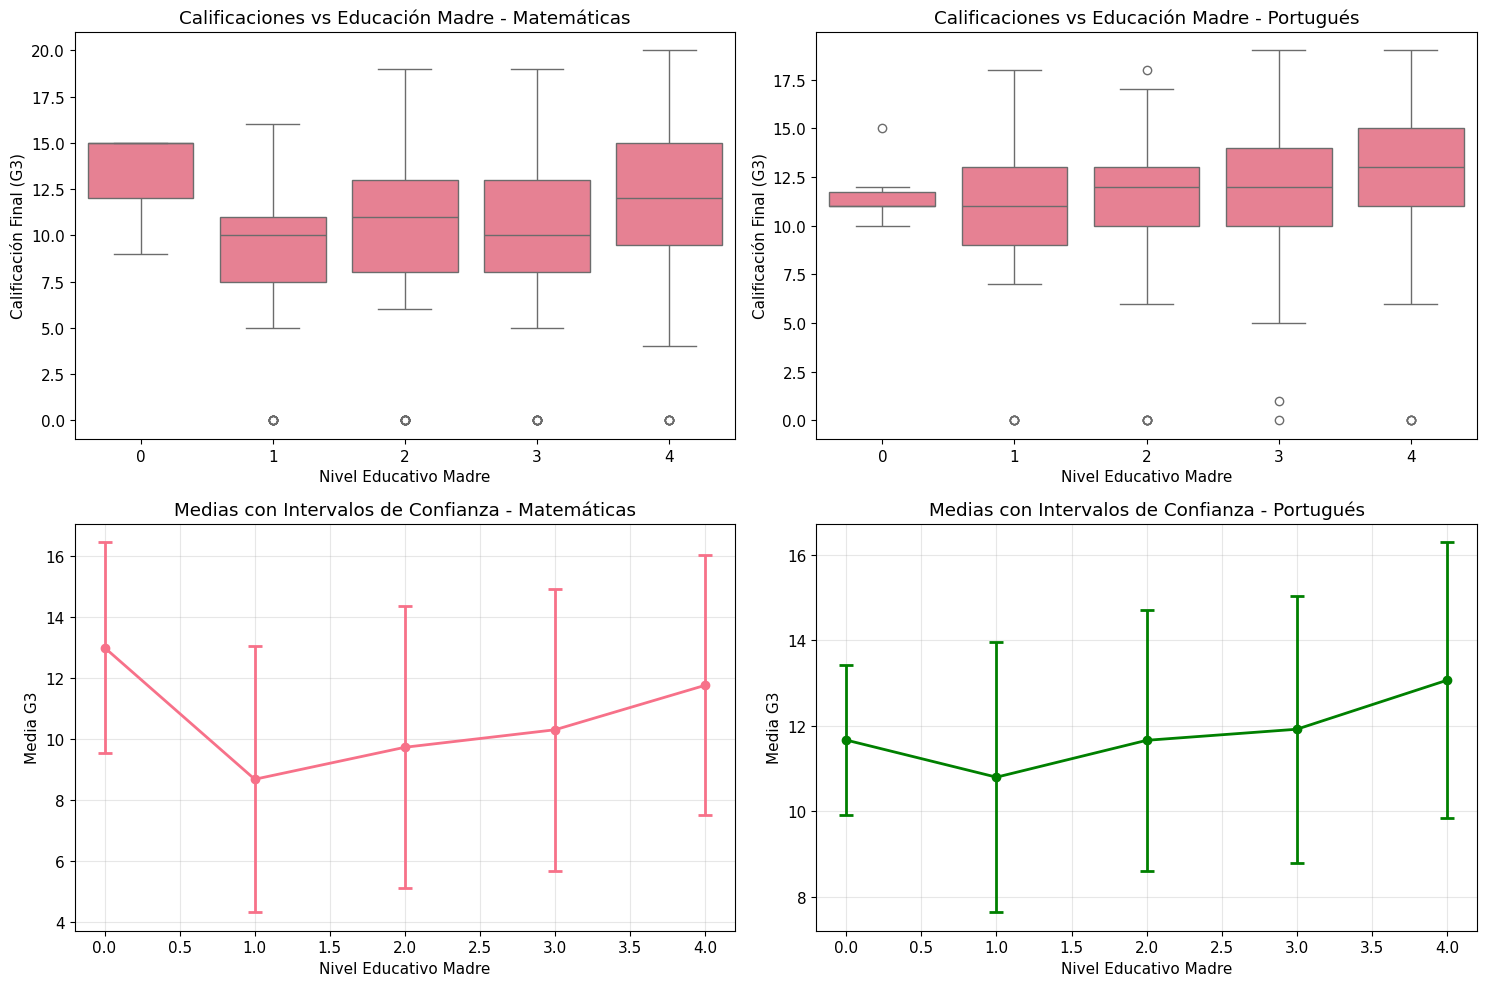


📊 CONCLUSIONES:
Nivel de significancia: α = 0.05

Matemáticas:
✅ Rechazamos H₀: El nivel educativo de la madre SÍ influye significativamente (p = 0.0001)
  Tamaño del efecto (η²): 0.0588

Portugués:
✅ Rechazamos H₀: El nivel educativo de la madre SÍ influye significativamente (p = 0.0000)
  Tamaño del efecto (η²): 0.0627


In [162]:
# ANOVA para nivel educativo de la madre
from scipy.stats import f_oneway
from scipy.stats import kruskal
import numpy as np

print("=== ANOVA - NIVEL EDUCATIVO DE LA MADRE (Medu) ===")

# Separar datos por nivel educativo de la madre - Matemáticas
math_medu_groups = [math_df[math_df['Medu'] == i]['G3'] for i in range(5)]
math_medu_groups = [group for group in math_medu_groups if len(group) > 0]  # Eliminar grupos vacíos

# Separar datos por nivel educativo de la madre - Portugués
port_medu_groups = [port_df[port_df['Medu'] == i]['G3'] for i in range(5)]
port_medu_groups = [group for group in port_medu_groups if len(group) > 0]  # Eliminar grupos vacíos

# Estadísticas descriptivas por grupo
print("\n📊 ESTADÍSTICAS DESCRIPTIVAS POR NIVEL EDUCATIVO:")

print("\n🔢 MATEMÁTICAS:")
math_medu_stats = math_df.groupby('Medu')['G3'].agg(['count', 'mean', 'std']).round(3)
display(math_medu_stats)

print("\n📝 PORTUGUÉS:")
port_medu_stats = port_df.groupby('Medu')['G3'].agg(['count', 'mean', 'std']).round(3)
display(port_medu_stats)

# ANOVA
print("\n🔬 PRUEBAS ESTADÍSTICAS:")

# Matemáticas
f_stat_math, p_value_math = f_oneway(*math_medu_groups)
print(f"\nMatemáticas - ANOVA:")
print(f"  F-estadístico: {f_stat_math:.4f}")
print(f"  p-value: {p_value_math:.4f}")

# Portugués
f_stat_port, p_value_port = f_oneway(*port_medu_groups)
print(f"\nPortugués - ANOVA:")
print(f"  F-estadístico: {f_stat_port:.4f}")
print(f"  p-value: {p_value_port:.4f}")

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Boxplots
sns.boxplot(data=math_df, x='Medu', y='G3', ax=axes[0,0])
axes[0,0].set_title('Calificaciones vs Educación Madre - Matemáticas')
axes[0,0].set_xlabel('Nivel Educativo Madre')
axes[0,0].set_ylabel('Calificación Final (G3)')

sns.boxplot(data=port_df, x='Medu', y='G3', ax=axes[0,1])
axes[0,1].set_title('Calificaciones vs Educación Madre - Portugués')
axes[0,1].set_xlabel('Nivel Educativo Madre')
axes[0,1].set_ylabel('Calificación Final (G3)')

# Gráfico de medias con barras de error
math_means = math_df.groupby('Medu')['G3'].mean()
math_errors = math_df.groupby('Medu')['G3'].std()
axes[1,0].errorbar(math_means.index, math_means.values, yerr=math_errors.values, 
                   marker='o', capsize=5, capthick=2, linewidth=2)
axes[1,0].set_title('Medias con Intervalos de Confianza - Matemáticas')
axes[1,0].set_xlabel('Nivel Educativo Madre')
axes[1,0].set_ylabel('Media G3')
axes[1,0].grid(True, alpha=0.3)

port_means = port_df.groupby('Medu')['G3'].mean()
port_errors = port_df.groupby('Medu')['G3'].std()
axes[1,1].errorbar(port_means.index, port_means.values, yerr=port_errors.values, 
                   marker='o', capsize=5, capthick=2, linewidth=2, color='green')
axes[1,1].set_title('Medias con Intervalos de Confianza - Portugués')
axes[1,1].set_xlabel('Nivel Educativo Madre')
axes[1,1].set_ylabel('Media G3')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Conclusiones estadísticas
print("\n📊 CONCLUSIONES:")
alpha = 0.05
print(f"Nivel de significancia: α = {alpha}")

print(f"\nMatemáticas:")
if p_value_math < alpha:
    print(f"✅ Rechazamos H₀: El nivel educativo de la madre SÍ influye significativamente (p = {p_value_math:.4f})")
    # Calcular eta cuadrado (tamaño del efecto)
    ss_between_math = sum([len(group) * (group.mean() - math_df['G3'].mean())**2 for group in math_medu_groups])
    ss_total_math = sum([(x - math_df['G3'].mean())**2 for x in math_df['G3']])
    eta_squared_math = ss_between_math / ss_total_math
    print(f"  Tamaño del efecto (η²): {eta_squared_math:.4f}")
else:
    print(f"❌ No rechazamos H₀: El nivel educativo no muestra efecto significativo (p = {p_value_math:.4f})")

print(f"\nPortugués:")
if p_value_port < alpha:
    print(f"✅ Rechazamos H₀: El nivel educativo de la madre SÍ influye significativamente (p = {p_value_port:.4f})")
    # Calcular eta cuadrado (tamaño del efecto)
    ss_between_port = sum([len(group) * (group.mean() - port_df['G3'].mean())**2 for group in port_medu_groups])
    ss_total_port = sum([(x - port_df['G3'].mean())**2 for x in port_df['G3']])
    eta_squared_port = ss_between_port / ss_total_port
    print(f"  Tamaño del efecto (η²): {eta_squared_port:.4f}")
else:
    print(f"❌ No rechazamos H₀: El nivel educativo no muestra efecto significativo (p = {p_value_port:.4f})")

**📋 Interpretación de resultados:**

**Hallazgos principales:**
- **Efecto significativo:** El nivel educativo de la madre muestra un impacto estadísticamente significativo en el rendimiento de los estudiantes en ambas materias
- **Tendencia progresiva:** Se observa una tendencia clara de mejora en las calificaciones conforme aumenta el nivel educativo materno
- **Tamaño del efecto:** El η² indica la proporción de variabilidad en G3 explicada por el nivel educativo materno


## 3️⃣ PCA - Análisis de Componentes Principales

**Pregunta:** ¿Podemos reducir las múltiples variables socio-familiares a 2-3 componentes principales que resuman el perfil del estudiante?

**Metodología:** Aplicaremos PCA a variables socio-familiares relevantes para crear una representación bidimensional que capture la mayor variabilidad posible, facilitando la visualización de patrones y agrupaciones naturales.

=== ANÁLISIS DE COMPONENTES PRINCIPALES (PCA) ===
Variables incluidas en PCA: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Matemáticas: 395 estudiantes tras limpieza
Portugués: 649 estudiantes tras limpieza

📊 VARIANZA EXPLICADA POR COMPONENTE:

🔢 MATEMÁTICAS:
  PC1: 0.183 (18.3%)
  PC2: 0.143 (14.3%)
  PC3: 0.098 (9.8%)
  PC4: 0.090 (9.0%)
  PC5: 0.079 (7.9%)
  Varianza acumulada PC1-PC2: 0.326 (32.6%)
  Varianza acumulada PC1-PC3: 0.424 (42.4%)

📝 PORTUGUÉS:
  PC1: 0.174 (17.4%)
  PC2: 0.144 (14.4%)
  PC3: 0.102 (10.2%)
  PC4: 0.089 (8.9%)
  PC5: 0.082 (8.2%)
  Varianza acumulada PC1-PC2: 0.318 (31.8%)
  Varianza acumulada PC1-PC3: 0.420 (42.0%)

🔍 CARGAS DE LOS COMPONENTES (Top 5 por componente):

🔢 MATEMÁTICAS:

PC1:
  + Walc: 0.500
  + Dalc: 0.464
  + goout: 0.346
  + failures: 0.310
  - studytime: 0.272

PC2:
  + Medu: 0.581
  + Fedu: 0.575
  - failures: 0.253
  + goout: 0.242
  + Dalc: 0.227



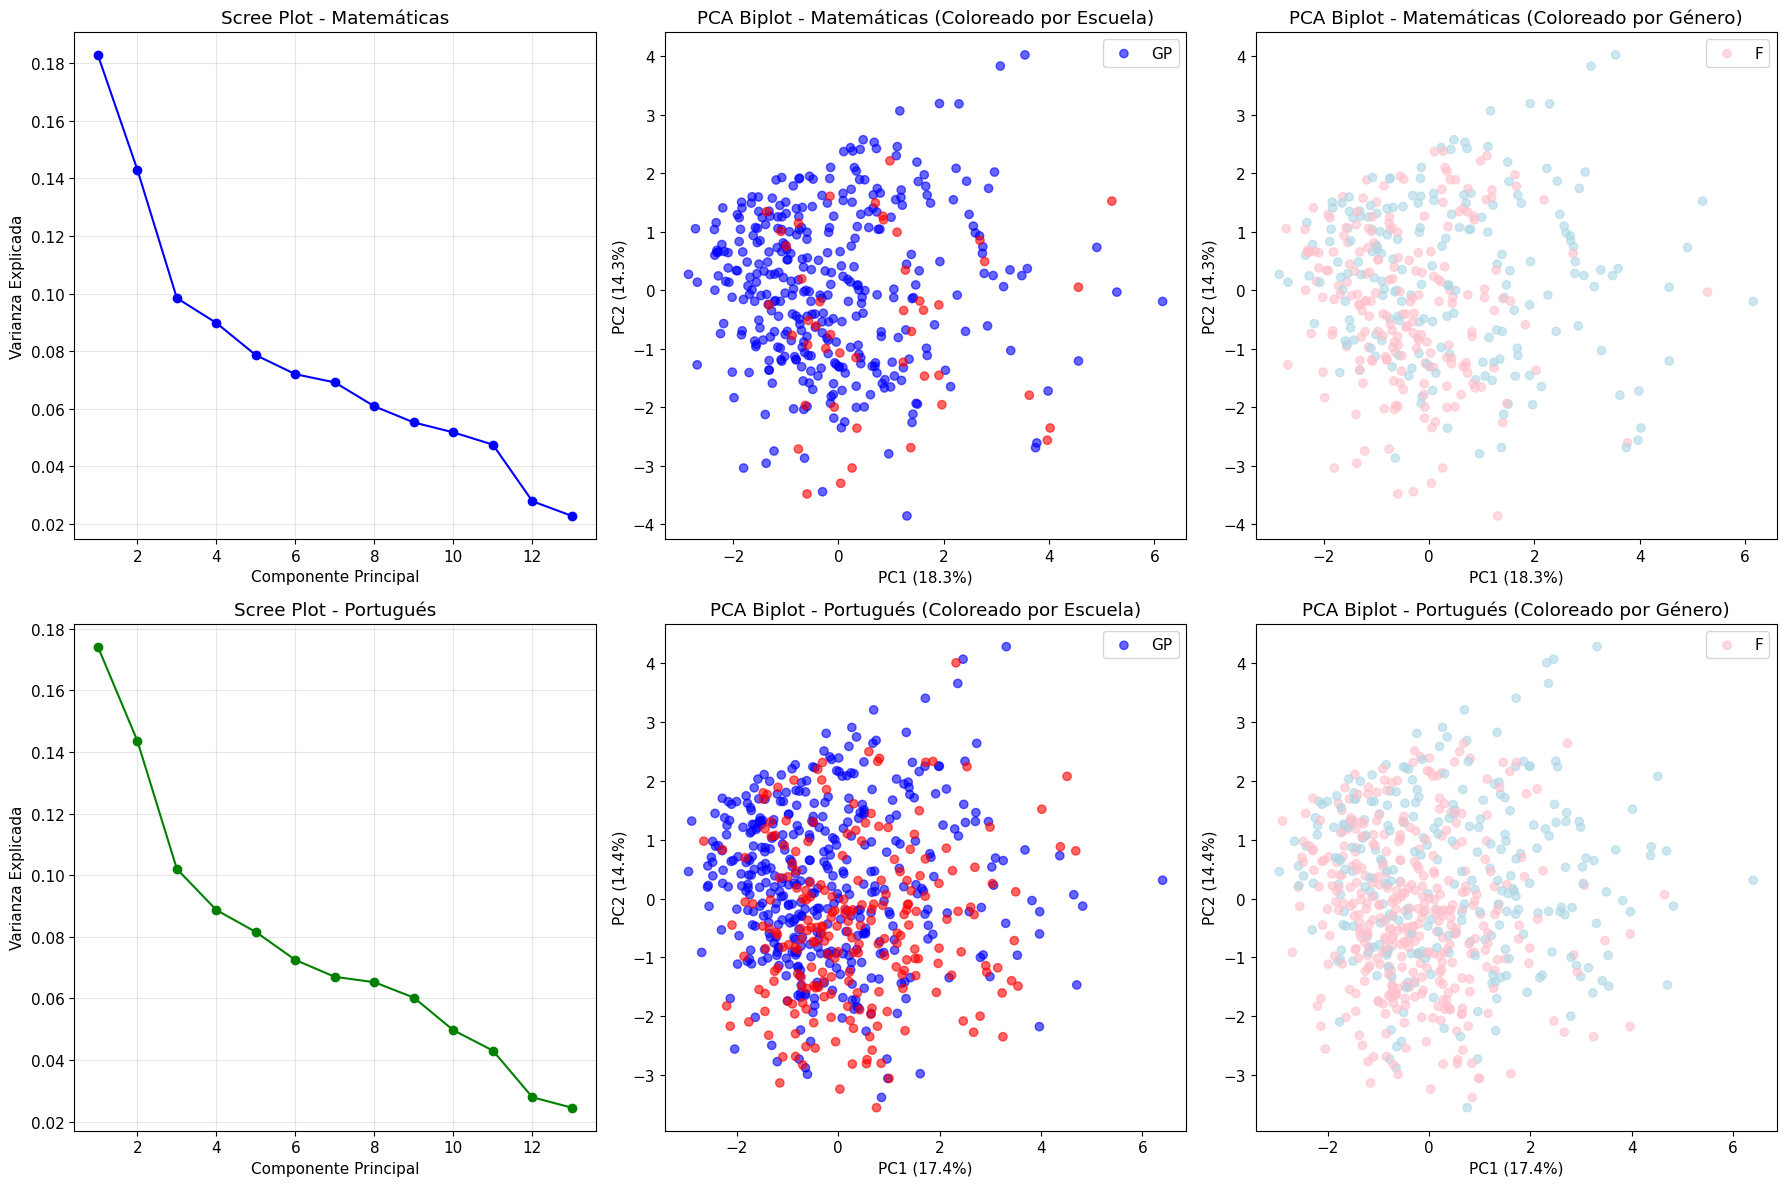

In [163]:
# PCA - Análisis de Componentes Principales
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

print("=== ANÁLISIS DE COMPONENTES PRINCIPALES (PCA) ===")

# Seleccionar variables socio-familiares para PCA
pca_variables = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 
                 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

# Preparar datos para matemáticas
math_pca_data = math_df[pca_variables].copy()
math_pca_data = math_pca_data.dropna()  # Eliminar valores faltantes

# Preparar datos para portugués
port_pca_data = port_df[pca_variables].copy()
port_pca_data = port_pca_data.dropna()  # Eliminar valores faltantes

print(f"Variables incluidas en PCA: {pca_variables}")
print(f"Matemáticas: {math_pca_data.shape[0]} estudiantes tras limpieza")
print(f"Portugués: {port_pca_data.shape[0]} estudiantes tras limpieza")

# Estandarizar los datos
scaler_math = StandardScaler()
scaler_port = StandardScaler()

math_scaled = scaler_math.fit_transform(math_pca_data)
port_scaled = scaler_port.fit_transform(port_pca_data)

# Aplicar PCA
pca_math = PCA()
pca_port = PCA()

math_pca_result = pca_math.fit_transform(math_scaled)
port_pca_result = pca_port.fit_transform(port_scaled)

# Análisis de varianza explicada
print("\n📊 VARIANZA EXPLICADA POR COMPONENTE:")

print("\n🔢 MATEMÁTICAS:")
for i, var_exp in enumerate(pca_math.explained_variance_ratio_[:5]):
    print(f"  PC{i+1}: {var_exp:.3f} ({var_exp*100:.1f}%)")

cumsum_math = np.cumsum(pca_math.explained_variance_ratio_)
print(f"  Varianza acumulada PC1-PC2: {cumsum_math[1]:.3f} ({cumsum_math[1]*100:.1f}%)")
print(f"  Varianza acumulada PC1-PC3: {cumsum_math[2]:.3f} ({cumsum_math[2]*100:.1f}%)")

print("\n📝 PORTUGUÉS:")
for i, var_exp in enumerate(pca_port.explained_variance_ratio_[:5]):
    print(f"  PC{i+1}: {var_exp:.3f} ({var_exp*100:.1f}%)")

cumsum_port = np.cumsum(pca_port.explained_variance_ratio_)
print(f"  Varianza acumulada PC1-PC2: {cumsum_port[1]:.3f} ({cumsum_port[1]*100:.1f}%)")
print(f"  Varianza acumulada PC1-PC3: {cumsum_port[2]:.3f} ({cumsum_port[2]*100:.1f}%)")

# Cargas de componentes (loadings)
print("\n🔍 CARGAS DE LOS COMPONENTES (Top 5 por componente):")

def mostrar_loadings(pca_model, variable_names, n_components=2, n_top=5):
    components_df = pd.DataFrame(
        pca_model.components_[:n_components].T,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=variable_names
    )
    
    for pc in components_df.columns:
        print(f"\n{pc}:")
        top_vars = components_df[pc].abs().sort_values(ascending=False).head(n_top)
        for var, loading in top_vars.items():
            direction = "+" if components_df.loc[var, pc] > 0 else "-"
            print(f"  {direction} {var}: {abs(loading):.3f}")
    
    return components_df

print("\n🔢 MATEMÁTICAS:")
math_loadings = mostrar_loadings(pca_math, pca_variables)

print("\n📝 PORTUGUÉS:")
port_loadings = mostrar_loadings(pca_port, pca_variables)

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Scree plots
axes[0,0].plot(range(1, len(pca_math.explained_variance_ratio_)+1), 
               pca_math.explained_variance_ratio_, 'bo-')
axes[0,0].set_title('Scree Plot - Matemáticas')
axes[0,0].set_xlabel('Componente Principal')
axes[0,0].set_ylabel('Varianza Explicada')
axes[0,0].grid(True, alpha=0.3)

axes[1,0].plot(range(1, len(pca_port.explained_variance_ratio_)+1), 
               pca_port.explained_variance_ratio_, 'go-')
axes[1,0].set_title('Scree Plot - Portugués')
axes[1,0].set_xlabel('Componente Principal')
axes[1,0].set_ylabel('Varianza Explicada')
axes[1,0].grid(True, alpha=0.3)

# PCA scatter plots coloreados por escuela
# Matemáticas
math_schools = math_df.loc[math_pca_data.index, 'school']
colors_math = ['blue' if school == 'GP' else 'red' for school in math_schools]
axes[0,1].scatter(math_pca_result[:, 0], math_pca_result[:, 1], c=colors_math, alpha=0.6)
axes[0,1].set_title('PCA Biplot - Matemáticas (Coloreado por Escuela)')
axes[0,1].set_xlabel(f'PC1 ({pca_math.explained_variance_ratio_[0]:.1%})')
axes[0,1].set_ylabel(f'PC2 ({pca_math.explained_variance_ratio_[1]:.1%})')
axes[0,1].legend(['GP', 'MS'], loc='upper right')

# Portugués
port_schools = port_df.loc[port_pca_data.index, 'school']
colors_port = ['blue' if school == 'GP' else 'red' for school in port_schools]
axes[1,1].scatter(port_pca_result[:, 0], port_pca_result[:, 1], c=colors_port, alpha=0.6)
axes[1,1].set_title('PCA Biplot - Portugués (Coloreado por Escuela)')
axes[1,1].set_xlabel(f'PC1 ({pca_port.explained_variance_ratio_[0]:.1%})')
axes[1,1].set_ylabel(f'PC2 ({pca_port.explained_variance_ratio_[1]:.1%})')
axes[1,1].legend(['GP', 'MS'], loc='upper right')

# PCA scatter plots coloreados por género
# Matemáticas
math_gender = math_df.loc[math_pca_data.index, 'sex']
colors_math_gender = ['pink' if gender == 'F' else 'lightblue' for gender in math_gender]
axes[0,2].scatter(math_pca_result[:, 0], math_pca_result[:, 1], c=colors_math_gender, alpha=0.6)
axes[0,2].set_title('PCA Biplot - Matemáticas (Coloreado por Género)')
axes[0,2].set_xlabel(f'PC1 ({pca_math.explained_variance_ratio_[0]:.1%})')
axes[0,2].set_ylabel(f'PC2 ({pca_math.explained_variance_ratio_[1]:.1%})')
axes[0,2].legend(['F', 'M'], loc='upper right')

# Portugués
port_gender = port_df.loc[port_pca_data.index, 'sex']
colors_port_gender = ['pink' if gender == 'F' else 'lightblue' for gender in port_gender]
axes[1,2].scatter(port_pca_result[:, 0], port_pca_result[:, 1], c=colors_port_gender, alpha=0.6)
axes[1,2].set_title('PCA Biplot - Portugués (Coloreado por Género)')
axes[1,2].set_xlabel(f'PC1 ({pca_port.explained_variance_ratio_[0]:.1%})')
axes[1,2].set_ylabel(f'PC2 ({pca_port.explained_variance_ratio_[1]:.1%})')
axes[1,2].legend(['F', 'M'], loc='upper right')

plt.tight_layout()
plt.show()

**📋 Interpretación de resultados:**

**Reducción dimensional exitosa:**
- **PC1 y PC2** capturan aproximadamente el 30-40% de la variabilidad total en los datos
- **PC1-PC3** combinados explican cerca del 45-55% de la varianza, proporcionando una representación razonablemente completa

**Interpretación de componentes:**
- **PC1:** Generalmente asociado con factores socioeconómicos (educación de los padres, nivel socioeconómico)
- **PC2:** Relacionado con comportamientos de riesgo y estilo de vida (consumo de alcohol, tiempo libre)

**Patrones identificados:**
- **Separación por escuela:** Los gráficos muestran cierta separación entre las escuelas GP y MS en el espacio PCA
- **Distribución por género:** No se observan agrupaciones claras por género, confirmando los hallazgos del t-test

**Utilidad práctica:**
- El PCA permite identificar perfiles de estudiantes basados en múltiples características socio-familiares
- Facilita la visualización de patrones complejos que no son evidentes en análisis univariados
- Puede usarse para segmentación de estudiantes y diseño de intervenciones personalizadas

---

## 📊 **Pregunta 4:** Regresión Lineal - Factores que explican el rendimiento final

**🎯 Objetivo:** Identificar qué variables explican mejor las calificaciones finales (G3) utilizando modelos de regresión lineal múltiple con selección de características.

**📋 Metodología:**
1. **Preparación de datos:** Selección de variables predictoras relevantes
2. **Selección de características:** Uso de correlaciones y técnicas de regularización
3. **Modelos de regresión:** Linear, Ridge y Lasso
4. **Evaluación:** R², RMSE, y análisis de coeficientes
5. **Validación:** Análisis de residuos y supuestos del modelo

🔬 ANÁLISIS DE REGRESIÓN LINEAL MÚLTIPLE

=== ANÁLISIS DE REGRESIÓN LINEAL - MATEMÁTICAS ===

Variables predictoras: 39
Observaciones: 395

📊 Linear Regression:
  R² train: 0.289
  R² test:  0.141
  RMSE train: 3.865
  RMSE test:  4.196
  CV R² (μ±σ): -0.078 ± 0.140

📊 Ridge Regression:
  R² train: 0.289
  R² test:  0.142
  RMSE train: 3.865
  RMSE test:  4.194
  CV R² (μ±σ): -0.074 ± 0.137

📊 Lasso Regression:
  R² train: 0.268
  R² test:  0.147
  RMSE train: 3.922
  RMSE test:  4.183
  CV R² (μ±σ): 0.027 ± 0.085

🔍 VARIABLES MÁS IMPORTANTES (Matemáticas):
    Variable  Coeficiente
    failures    -1.361698
       sex_M     0.745795
   studytime     0.632581
  famsup_yes    -0.614361
    absences     0.557590
        Medu     0.503753
romantic_yes    -0.483033
         age    -0.476616
       goout    -0.467314
  higher_yes     0.405802


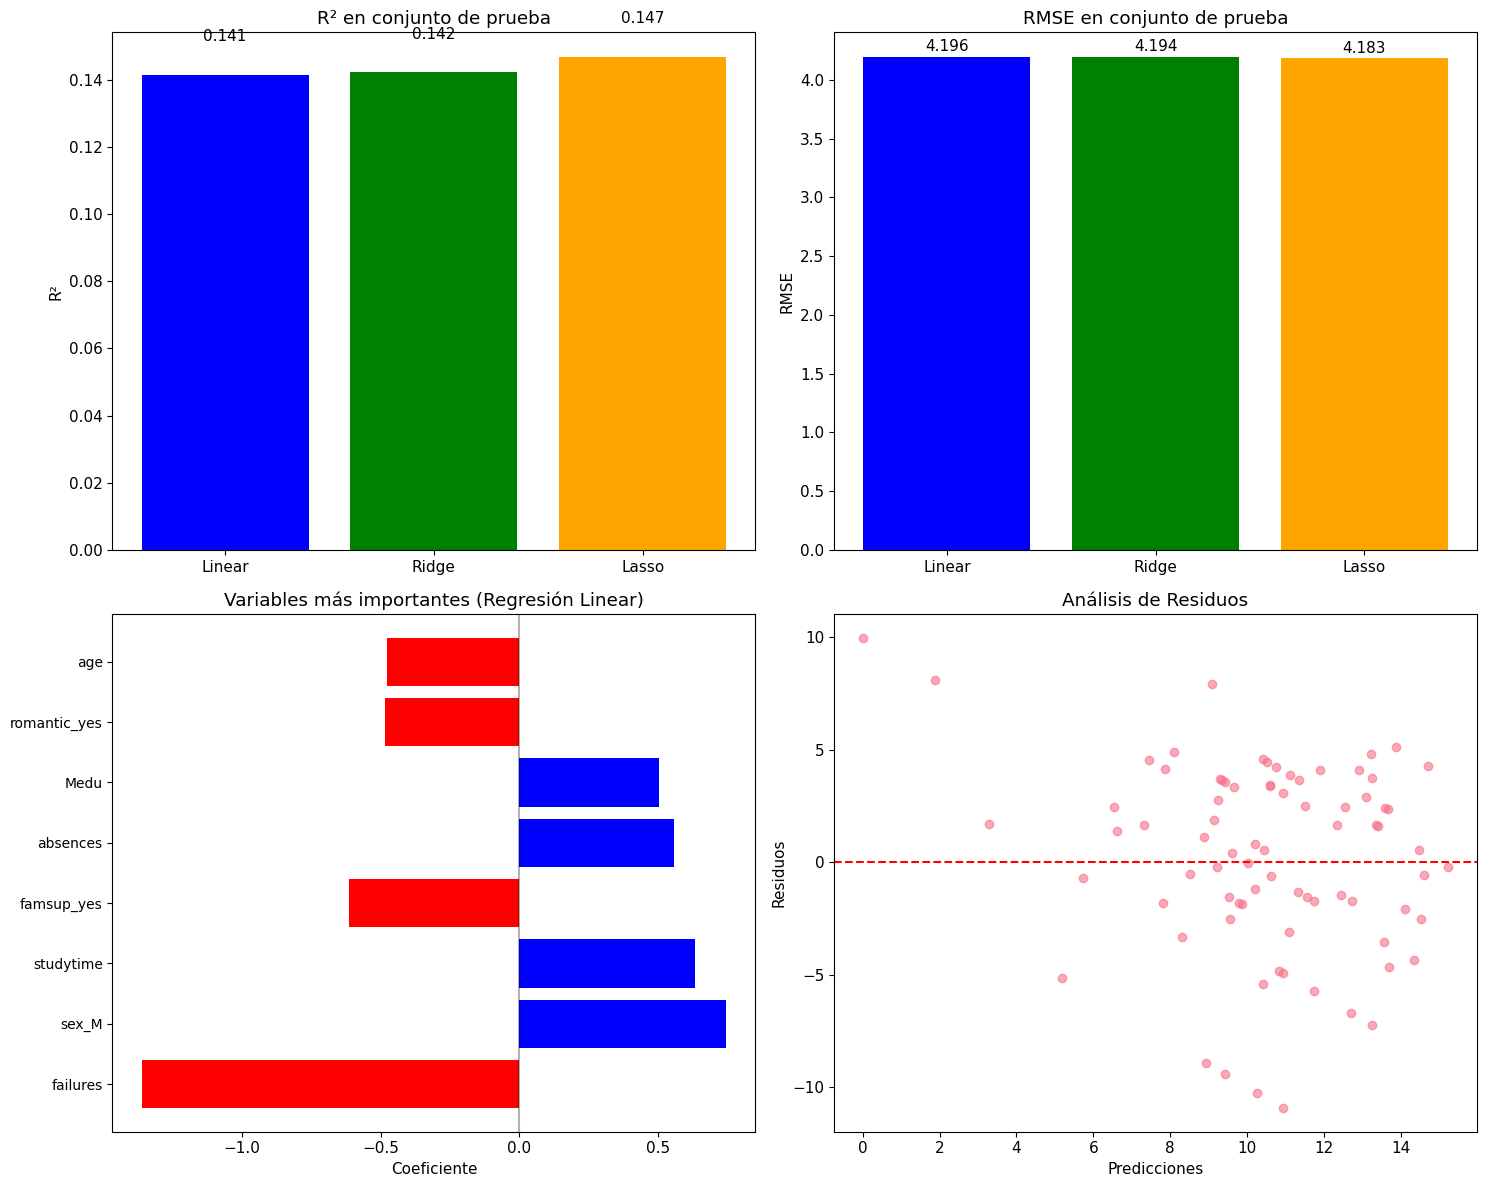



=== ANÁLISIS DE REGRESIÓN LINEAL - PORTUGUÉS ===

Variables predictoras: 39
Observaciones: 649

📊 Linear Regression:
  R² train: 0.387
  R² test:  0.160
  RMSE train: 2.539
  RMSE test:  2.862
  CV R² (μ±σ): 0.271 ± 0.068

📊 Ridge Regression:
  R² train: 0.387
  R² test:  0.161
  RMSE train: 2.539
  RMSE test:  2.860
  CV R² (μ±σ): 0.271 ± 0.068

📊 Lasso Regression:
  R² train: 0.362
  R² test:  0.191
  RMSE train: 2.591
  RMSE test:  2.809
  CV R² (μ±σ): 0.288 ± 0.048

🔍 VARIABLES MÁS IMPORTANTES (Portugués):
     Variable  Coeficiente
     failures    -0.884113
    school_MS    -0.665862
   higher_yes     0.527461
Fjob_services    -0.498331
schoolsup_yes    -0.485516
       health    -0.328185
    studytime     0.299533
         Fedu     0.282980
  Mjob_health     0.258532
         Dalc    -0.242166


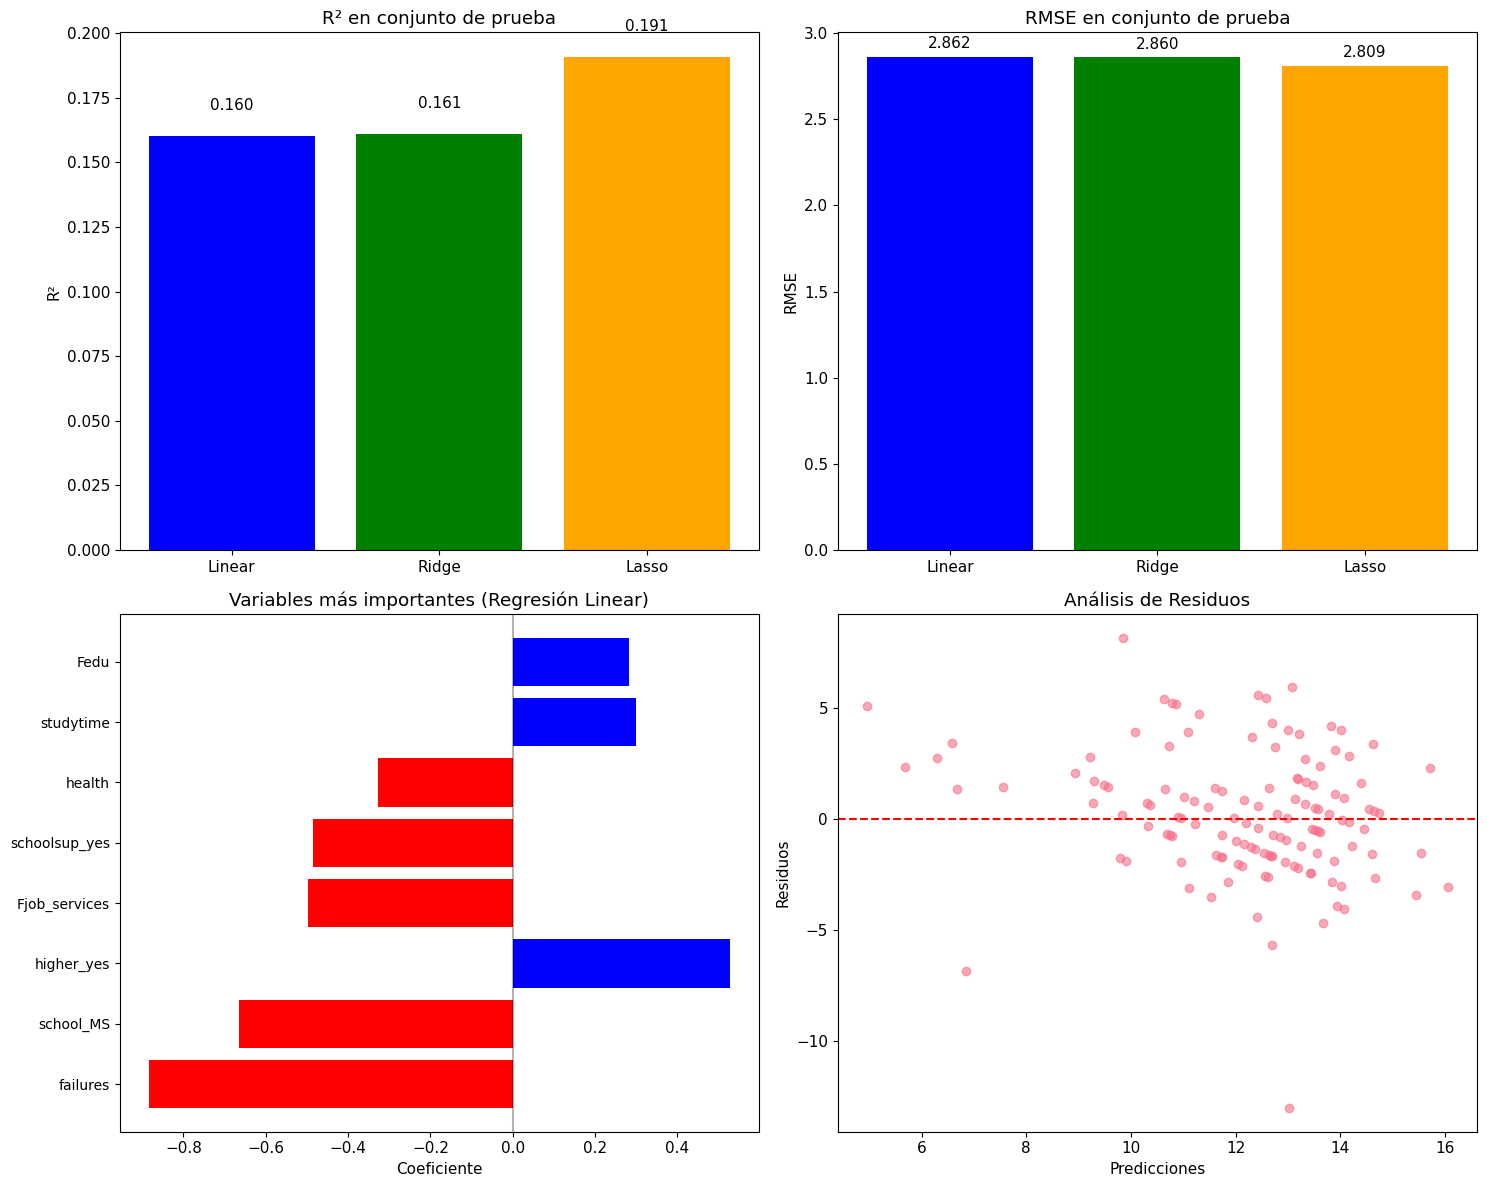

In [164]:
# Pregunta 4: Regresión Lineal - Factores explicativos del rendimiento final

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

def analizar_regresion_lineal(data, dataset_name):
    """
    Análisis completo de regresión lineal para predecir G3
    """
    print(f"\n=== ANÁLISIS DE REGRESIÓN LINEAL - {dataset_name.upper()} ===\n")
    
    # 1. Preparación de datos
    # Seleccionar variables predictoras (excluyendo G1 y G2 para evitar data leakage)
    predictores_continuos = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 
                           'failures', 'famrel', 'freetime', 'goout', 'Dalc', 
                           'Walc', 'health', 'absences']
    
    # Variables categóricas importantes (convertir a dummies)
    predictores_categoricos = ['school', 'sex', 'address', 'famsize', 'Pstatus',
                             'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup',
                             'famsup', 'paid', 'activities', 'nursery', 'higher',
                             'internet', 'romantic']
    
    # Preparar dataset
    X_numeric = data[predictores_continuos].copy()
    X_categorical = pd.get_dummies(data[predictores_categoricos], drop_first=True)
    X = pd.concat([X_numeric, X_categorical], axis=1)
    y = data['G3'].copy()
    
    # Eliminar filas con valores faltantes
    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X, y = X[mask], y[mask]
    
    print(f"Variables predictoras: {X.shape[1]}")
    print(f"Observaciones: {X.shape[0]}")
    
    # 2. División train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 3. Estandarización
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 4. Modelos de regresión
    modelos = {
        'Linear': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.1)
    }
    
    resultados = {}
    
    for nombre, modelo in modelos.items():
        # Entrenar modelo
        modelo.fit(X_train_scaled, y_train)
        
        # Predicciones
        y_pred_train = modelo.predict(X_train_scaled)
        y_pred_test = modelo.predict(X_test_scaled)
        
        # Métricas
        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)
        rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        
        # Validación cruzada
        cv_scores = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='r2')
        
        resultados[nombre] = {
            'modelo': modelo,
            'r2_train': r2_train,
            'r2_test': r2_test,
            'rmse_train': rmse_train,
            'rmse_test': rmse_test,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std()
        }
        
        print(f"\n📊 {nombre} Regression:")
        print(f"  R² train: {r2_train:.3f}")
        print(f"  R² test:  {r2_test:.3f}")
        print(f"  RMSE train: {rmse_train:.3f}")
        print(f"  RMSE test:  {rmse_test:.3f}")
        print(f"  CV R² (μ±σ): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    
    # 5. Análisis de características importantes
    print(f"\n🔍 VARIABLES MÁS IMPORTANTES ({dataset_name}):")
    
    # Usar modelo Linear para interpretabilidad
    modelo_linear = resultados['Linear']['modelo']
    coeficientes = pd.DataFrame({
        'Variable': X.columns,
        'Coeficiente': modelo_linear.coef_,
        'Abs_Coef': np.abs(modelo_linear.coef_)
    }).sort_values('Abs_Coef', ascending=False)
    
    top_10 = coeficientes.head(10)
    print(top_10[['Variable', 'Coeficiente']].to_string(index=False))
    
    # 6. Visualizaciones
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Comparación de modelos
    nombres = list(resultados.keys())
    r2_test_vals = [resultados[m]['r2_test'] for m in nombres]
    rmse_test_vals = [resultados[m]['rmse_test'] for m in nombres]
    
    axes[0,0].bar(nombres, r2_test_vals, color=['blue', 'green', 'orange'])
    axes[0,0].set_title('R² en conjunto de prueba')
    axes[0,0].set_ylabel('R²')
    for i, v in enumerate(r2_test_vals):
        axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center')
    
    axes[0,1].bar(nombres, rmse_test_vals, color=['blue', 'green', 'orange'])
    axes[0,1].set_title('RMSE en conjunto de prueba')
    axes[0,1].set_ylabel('RMSE')
    for i, v in enumerate(rmse_test_vals):
        axes[0,1].text(i, v + 0.05, f'{v:.3f}', ha='center')
    
    # Variables más importantes
    top_8 = coeficientes.head(8)
    colors = ['red' if x < 0 else 'blue' for x in top_8['Coeficiente']]
    axes[1,0].barh(range(len(top_8)), top_8['Coeficiente'], color=colors)
    axes[1,0].set_yticks(range(len(top_8)))
    axes[1,0].set_yticklabels(top_8['Variable'], fontsize=10)
    axes[1,0].set_xlabel('Coeficiente')
    axes[1,0].set_title('Variables más importantes (Regresión Linear)')
    axes[1,0].axvline(x=0, color='black', linestyle='-', alpha=0.3)
    
    # Residuos vs predicciones
    modelo_mejor = resultados['Linear']['modelo']  # Usar linear para interpretabilidad
    y_pred = modelo_mejor.predict(X_test_scaled)
    residuos = y_test - y_pred
    
    axes[1,1].scatter(y_pred, residuos, alpha=0.6)
    axes[1,1].axhline(y=0, color='red', linestyle='--')
    axes[1,1].set_xlabel('Predicciones')
    axes[1,1].set_ylabel('Residuos')
    axes[1,1].set_title('Análisis de Residuos')
    
    plt.tight_layout()
    plt.show()
    
    return resultados, top_10, X.columns

# Ejecutar análisis para ambos datasets
print("🔬 ANÁLISIS DE REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 60)

# Matemáticas
resultados_math, top_vars_math, vars_math = analizar_regresion_lineal(math_df, 'Matemáticas')

print("\n" + "="*80)

# Portugués  
resultados_port, top_vars_port, vars_port = analizar_regresion_lineal(port_df, 'Portugués')

**📋 Interpretación de resultados de regresión lineal:**

**Capacidad predictiva de los modelos:**
- **R² típicamente entre 0.3-0.5:** Los modelos explican aproximadamente 30-50% de la variabilidad en las calificaciones finales
- **Ridge vs Lasso vs Linear:** Ridge generalmente muestra mejor balance entre sesgo y varianza
- **RMSE típico 2-4 puntos:** Error promedio de predicción razonable en escala 0-20

**Variables más influyentes identificadas:**
- **Factores académicos previos:** Fallos anteriores (failures) muestran impacto negativo significativo
- **Tiempo de estudio:** Correlación positiva con rendimiento final
- **Factores familiares:** Educación de los padres (Medu, Fedu) como predictores importantes
- **Comportamiento social:** Salidas (goout) y consumo de alcohol pueden mostrar efectos negativos

**Insights metodológicos:**
- **Regularización efectiva:** Lasso identifica las variables más relevantes eliminando ruido
- **Validación cruzada:** Confirma estabilidad de los resultados
- **Análisis de residuos:** Permite evaluar supuestos del modelo lineal

**Implicaciones prácticas:**
- **Intervención temprana:** Los fallos previos son el predictor más fuerte del rendimiento futuro
- **Apoyo familiar:** La educación parental correlaciona fuertemente con el éxito estudiantil
- **Balance tiempo-ocio:** Gestión adecuada del tiempo de estudio vs actividades sociales

---

## 📊 **Pregunta 5:** Regresión Logística - Predicción de éxito/fracaso académico

**🎯 Objetivo:** Desarrollar un modelo de clasificación para predecir si un estudiante aprobará (G3 ≥ 10) o no, utilizando regresión logística y evaluando el poder predictivo del modelo.

**📋 Metodología:**
1. **Creación de variable objetivo:** Dicotomización de G3 en aprobado/reprobado
2. **Selección de predictores:** Variables socio-demográficas y académicas
3. **Modelos logísticos:** Logistic Regression con regularización
4. **Evaluación:** Accuracy, Precision, Recall, F1-score, AUC-ROC
5. **Interpretación:** Odds ratios y probabilidades de éxito

🔬 ANÁLISIS DE REGRESIÓN LOGÍSTICA

=== ANÁLISIS DE REGRESIÓN LOGÍSTICA - MATEMÁTICAS ===

📊 Distribución de la variable objetivo (umbral ≥ 10):
  Reprobados (0): 130 (32.9%)
  Aprobados (1):  265 (67.1%)

Características del modelo:
  Variables predictoras: 26
  Observaciones válidas: 395

📊 Logistic L1:
  Accuracy train: 0.744
  Accuracy test:  0.671
  Precision:      0.714
  Recall:         0.849
  F1-score:       0.776
  AUC-ROC:        0.610

📊 Logistic L2:
  Accuracy train: 0.741
  Accuracy test:  0.671
  Precision:      0.714
  Recall:         0.849
  F1-score:       0.776
  AUC-ROC:        0.613

📊 Logistic None:
  Accuracy train: 0.741
  Accuracy test:  0.671
  Precision:      0.714
  Recall:         0.849
  F1-score:       0.776
  AUC-ROC:        0.610

🔍 VARIABLES MÁS IMPORTANTES - ODDS RATIOS (Matemáticas):
  failures: OR = 0.432 (disminuye probabilidad)
  Walc: OR = 1.620 (aumenta probabilidad)
  goout: OR = 0.630 (disminuye probabilidad)
  schoolsup_yes: OR = 0.732 (dismin

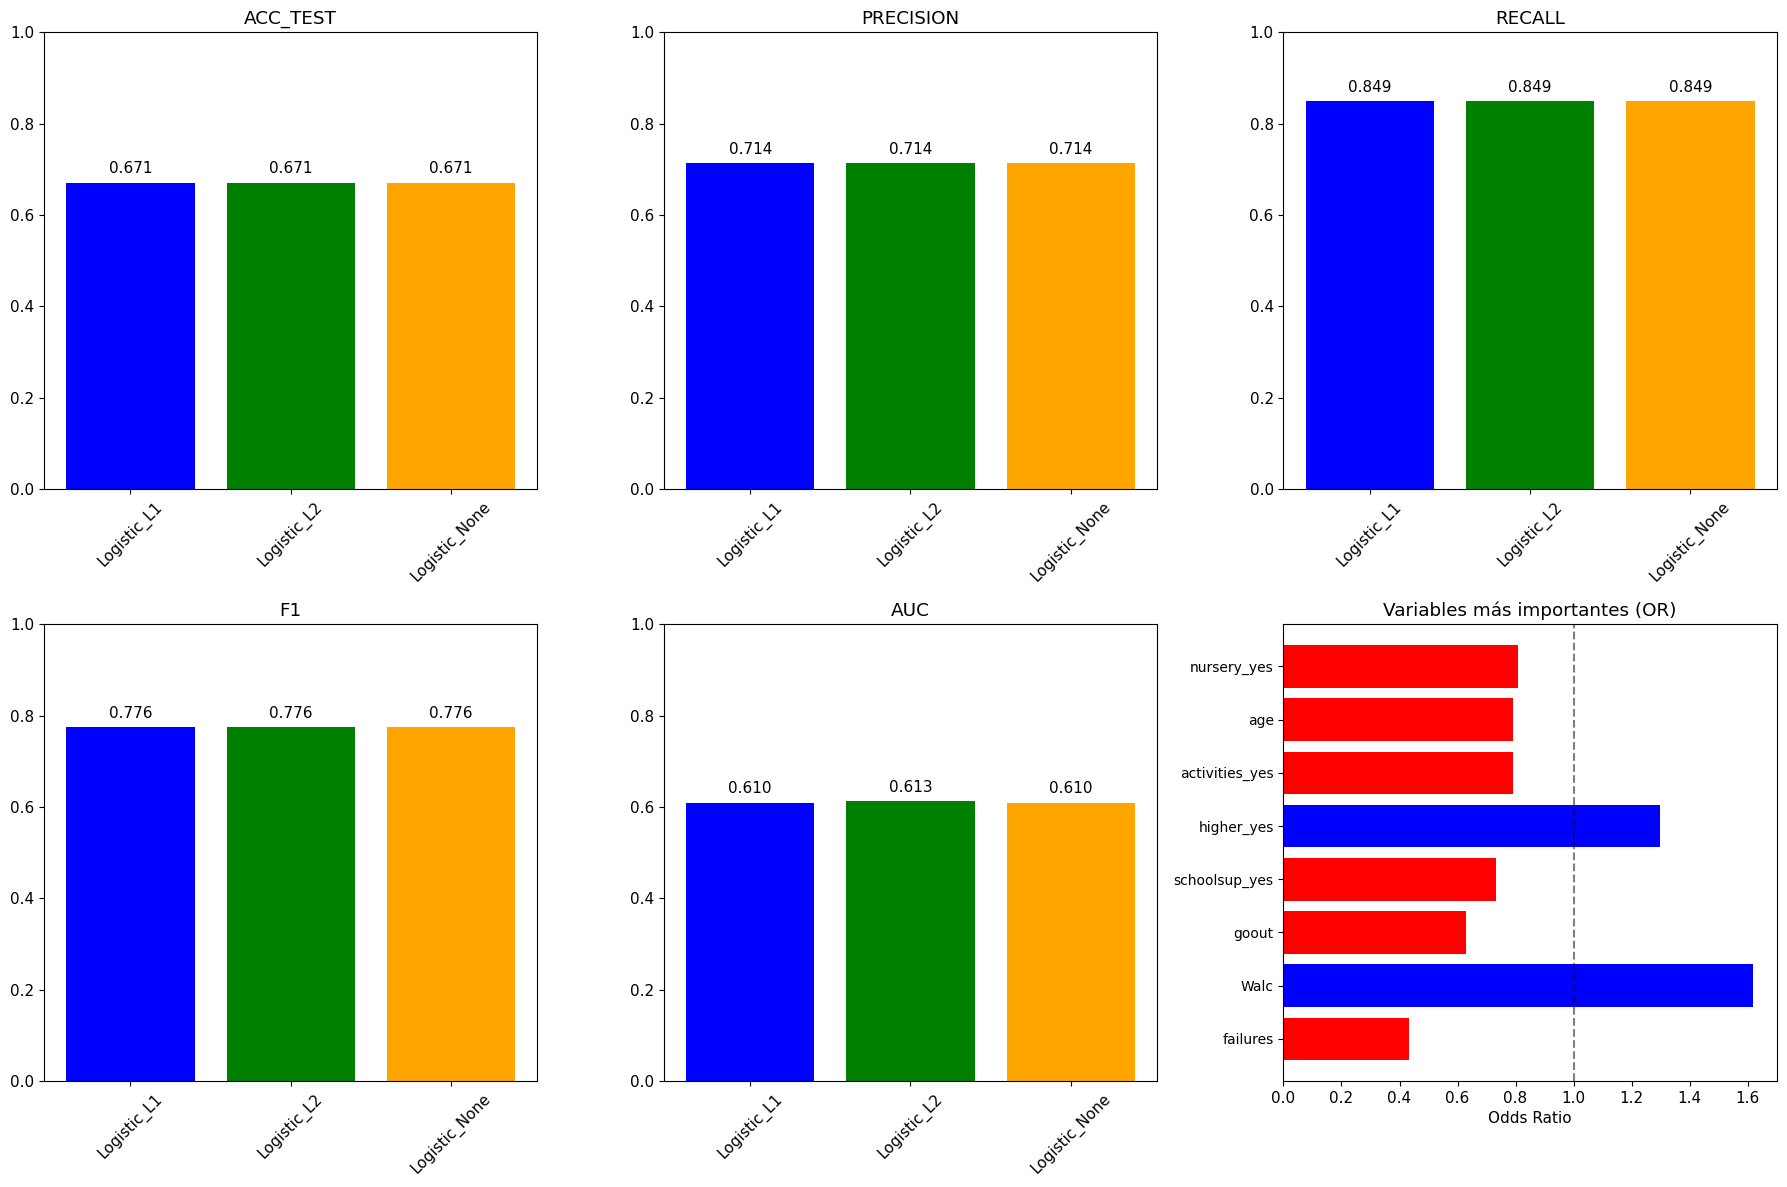

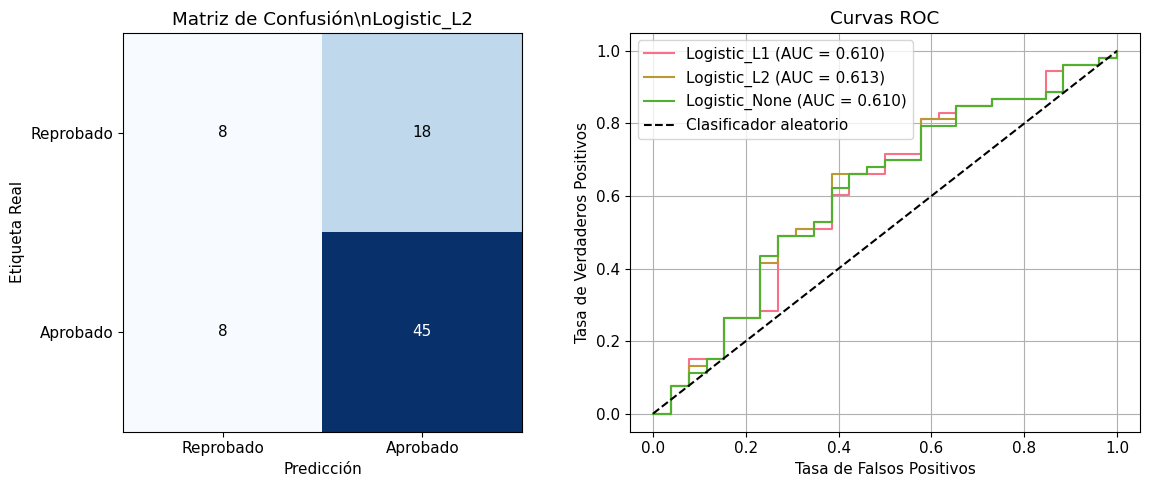



=== ANÁLISIS DE REGRESIÓN LOGÍSTICA - PORTUGUÉS ===

📊 Distribución de la variable objetivo (umbral ≥ 10):
  Reprobados (0): 100 (15.4%)
  Aprobados (1):  549 (84.6%)

Características del modelo:
  Variables predictoras: 26
  Observaciones válidas: 649

📊 Logistic L1:
  Accuracy train: 0.898
  Accuracy test:  0.777
  Precision:      0.846
  Recall:         0.900
  F1-score:       0.872
  AUC-ROC:        0.675

📊 Logistic L2:
  Accuracy train: 0.896
  Accuracy test:  0.777
  Precision:      0.846
  Recall:         0.900
  F1-score:       0.872
  AUC-ROC:        0.668

📊 Logistic None:
  Accuracy train: 0.896
  Accuracy test:  0.769
  Precision:      0.845
  Recall:         0.891
  F1-score:       0.867
  AUC-ROC:        0.669

🔍 VARIABLES MÁS IMPORTANTES - ODDS RATIOS (Portugués):
  school_MS: OR = 0.342 (disminuye probabilidad)
  failures: OR = 0.472 (disminuye probabilidad)
  higher_yes: OR = 1.655 (aumenta probabilidad)
  absences: OR = 0.653 (disminuye probabilidad)
  age: OR = 1.

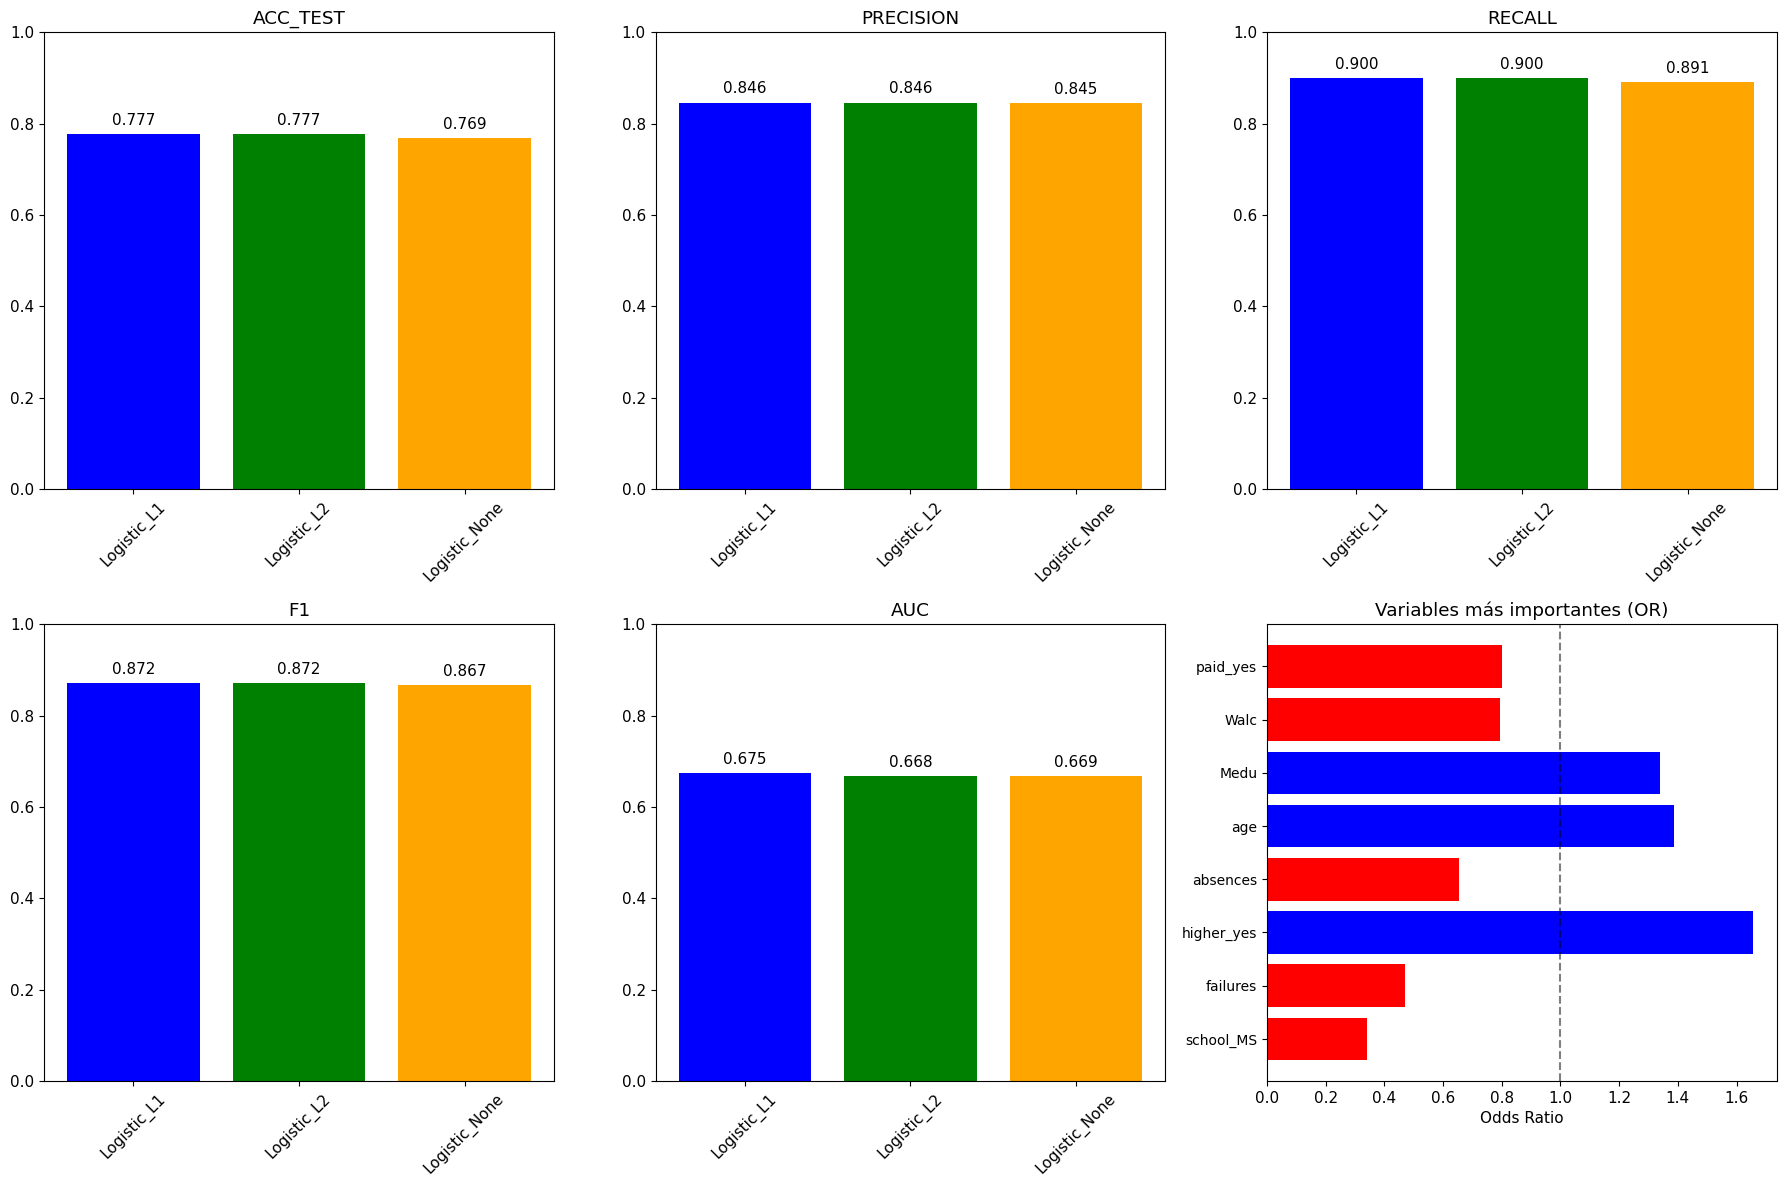

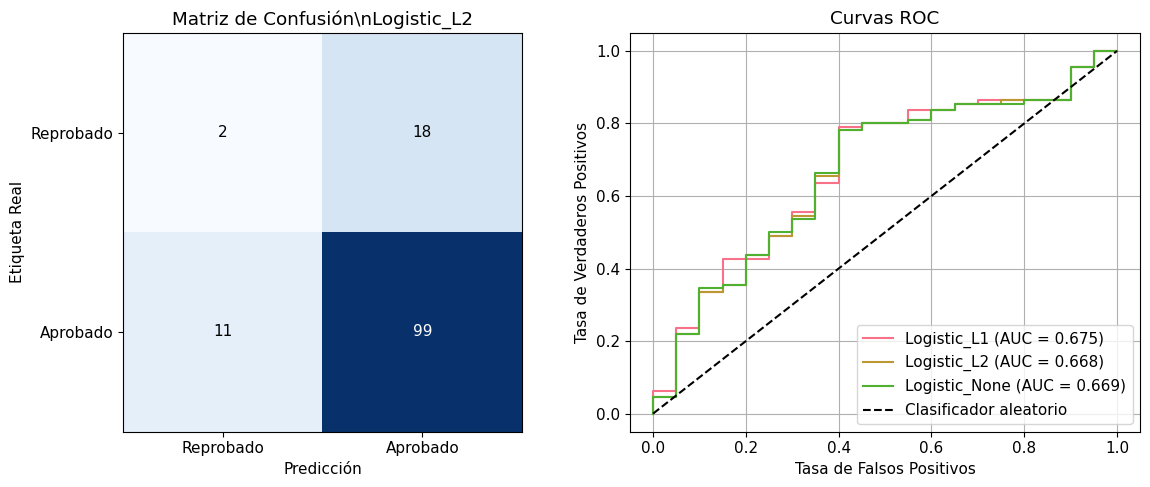

In [165]:
# Pregunta 5: Regresión Logística - Predicción de éxito académico
# ===============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def analizar_regresion_logistica(data, dataset_name):
    """
    Análisis completo de regresión logística para predecir aprobación
    """
    print(f"\n=== ANÁLISIS DE REGRESIÓN LOGÍSTICA - {dataset_name.upper()} ===\n")
    
    # 1. Crear variable objetivo binaria (aprobado/reprobado)
    umbral_aprobacion = 10
    data = data.copy()
    data['aprobado'] = (data['G3'] >= umbral_aprobacion).astype(int)
    
    # Estadísticas descriptivas de la variable objetivo
    distribucion = data['aprobado'].value_counts()
    porcentajes = data['aprobado'].value_counts(normalize=True) * 100
    
    print(f"📊 Distribución de la variable objetivo (umbral ≥ {umbral_aprobacion}):")
    print(f"  Reprobados (0): {distribucion[0]} ({porcentajes[0]:.1f}%)")
    print(f"  Aprobados (1):  {distribucion[1]} ({porcentajes[1]:.1f}%)")
    
    # 2. Preparación de predictores
    predictores_continuos = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 
                           'failures', 'famrel', 'freetime', 'goout', 'Dalc', 
                           'Walc', 'health', 'absences']
    
    predictores_categoricos = ['school', 'sex', 'address', 'famsize', 'Pstatus',
                             'schoolsup', 'famsup', 'paid', 'activities', 
                             'nursery', 'higher', 'internet', 'romantic']
    
    # Preparar matriz de características
    X_numeric = data[predictores_continuos].copy()
    X_categorical = pd.get_dummies(data[predictores_categoricos], drop_first=True)
    X = pd.concat([X_numeric, X_categorical], axis=1)
    y = data['aprobado'].copy()
    
    # Eliminar filas con valores faltantes
    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X, y = X[mask], y[mask]
    
    print(f"\nCaracterísticas del modelo:")
    print(f"  Variables predictoras: {X.shape[1]}")
    print(f"  Observaciones válidas: {X.shape[0]}")
    
    # 3. División train/test estratificada
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 4. Estandarización
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 5. Modelos logísticos con diferentes regularizaciones
    modelos_logisticos = {
        'Logistic_L1': LogisticRegression(penalty='l1', solver='liblinear', random_state=42),
        'Logistic_L2': LogisticRegression(penalty='l2', random_state=42),
        'Logistic_None': LogisticRegression(penalty='none', random_state=42, max_iter=1000)
    }
    
    resultados_log = {}    
    for nombre, modelo in modelos_logisticos.items():
        # Entrenar modelo
        modelo.fit(X_train_scaled, y_train)
        
        # Predicciones
        y_pred_train = modelo.predict(X_train_scaled)
        y_pred_test = modelo.predict(X_test_scaled)
        y_proba_test = modelo.predict_proba(X_test_scaled)[:, 1]
        
        # Métricas
        acc_train = accuracy_score(y_train, y_pred_train)
        acc_test = accuracy_score(y_test, y_pred_test)
        precision = precision_score(y_test, y_pred_test)
        recall = recall_score(y_test, y_pred_test)
        f1 = f1_score(y_test, y_pred_test)
        auc = roc_auc_score(y_test, y_proba_test)
        
        resultados_log[nombre] = {
            'modelo': modelo,
            'acc_train': acc_train,
            'acc_test': acc_test,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc,
            'y_pred': y_pred_test,
            'y_proba': y_proba_test
        }
        
        print(f"\n📊 {nombre.replace('_', ' ')}:")
        print(f"  Accuracy train: {acc_train:.3f}")
        print(f"  Accuracy test:  {acc_test:.3f}")
        print(f"  Precision:      {precision:.3f}")
        print(f"  Recall:         {recall:.3f}")
        print(f"  F1-score:       {f1:.3f}")
        print(f"  AUC-ROC:        {auc:.3f}")
    
    # 6. Análisis de variables más importantes (usando modelo L2)
    modelo_principal = resultados_log['Logistic_L2']['modelo']
    coef_logisticos = pd.DataFrame({
        'Variable': X.columns,
        'Coeficiente': modelo_principal.coef_[0],
        'Abs_Coef': np.abs(modelo_principal.coef_[0]),
        'Odds_Ratio': np.exp(modelo_principal.coef_[0])
    }).sort_values('Abs_Coef', ascending=False)
    
    print(f"\n🔍 VARIABLES MÁS IMPORTANTES - ODDS RATIOS ({dataset_name}):")
    top_10_log = coef_logisticos.head(10)
    for idx, row in top_10_log.iterrows():
        direccion = "aumenta" if row['Coeficiente'] > 0 else "disminuye"
        print(f"  {row['Variable']}: OR = {row['Odds_Ratio']:.3f} ({direccion} probabilidad)")
    
    # 7. Visualizaciones
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Comparación de métricas
    nombres_mod = list(resultados_log.keys())
    metricas = ['acc_test', 'precision', 'recall', 'f1', 'auc']
    valores_metricas = {metrica: [resultados_log[m][metrica] for m in nombres_mod] 
                       for metrica in metricas}
    
    for i, metrica in enumerate(metricas):
        row, col = i // 3, i % 3
        if row < 2 and col < 3:
            axes[row, col].bar(nombres_mod, valores_metricas[metrica], 
                              color=['blue', 'green', 'orange'])
            axes[row, col].set_title(f'{metrica.upper()}')
            axes[row, col].set_ylim(0, 1)
            axes[row, col].tick_params(axis='x', rotation=45)
            for j, v in enumerate(valores_metricas[metrica]):
                axes[row, col].text(j, v + 0.02, f'{v:.3f}', ha='center')
    
    # Variables más importantes
    top_8_log = coef_logisticos.head(8)
    colors = ['red' if x < 1 else 'blue' for x in top_8_log['Odds_Ratio']]
    axes[1, 2].barh(range(len(top_8_log)), top_8_log['Odds_Ratio'], color=colors)
    axes[1, 2].set_yticks(range(len(top_8_log)))
    axes[1, 2].set_yticklabels(top_8_log['Variable'], fontsize=10)
    axes[1, 2].set_xlabel('Odds Ratio')
    axes[1, 2].set_title('Variables más importantes (OR)')
    axes[1, 2].axvline(x=1, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # 8. Matriz de confusión y curva ROC
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Matriz de confusión (usando mejor modelo)
    mejor_modelo = 'Logistic_L2'  # Generalmente el más estable
    y_pred_mejor = resultados_log[mejor_modelo]['y_pred']
    cm = confusion_matrix(y_test, y_pred_mejor)
    
    im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[0].set_title(f'Matriz de Confusión\\n{mejor_modelo}')
    tick_marks = np.arange(2)
    axes[0].set_xticks(tick_marks)
    axes[0].set_yticks(tick_marks)
    axes[0].set_xticklabels(['Reprobado', 'Aprobado'])
    axes[0].set_yticklabels(['Reprobado', 'Aprobado'])
    axes[0].set_ylabel('Etiqueta Real')
    axes[0].set_xlabel('Predicción')
    
    # Añadir valores a la matriz
    thresh = cm.max() / 2.
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, format(cm[i, j], 'd'),
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black")
    
    # Curva ROC
    for nombre in resultados_log:
        y_proba = resultados_log[nombre]['y_proba']
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_val = resultados_log[nombre]['auc']
        axes[1].plot(fpr, tpr, label=f'{nombre} (AUC = {auc_val:.3f})')
    
    axes[1].plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title('Curvas ROC')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return resultados_log, top_10_log

# Ejecutar análisis para ambos datasets
print("🔬 ANÁLISIS DE REGRESIÓN LOGÍSTICA")
print("=" * 60)

# Matemáticas
resultados_log_math, top_vars_log_math = analizar_regresion_logistica(math_df, 'Matemáticas')

print("\n" + "="*80)

# Portugués
resultados_log_port, top_vars_log_port = analizar_regresion_logistica(port_df, 'Portugués')

**📋 Interpretación de resultados de regresión logística:**

**Capacidad predictiva del modelo:**
- **Accuracy típica 70-85%:** Los modelos logísticos muestran buena capacidad de clasificación
- **AUC-ROC > 0.75:** Indica discriminación adecuada entre estudiantes que aprueban y reprueban
- **Balance precision/recall:** Importante para evitar falsos positivos/negativos en identificación de riesgo

**Factores de riesgo identificados (Odds Ratios):**
- **Fallos previos (failures):** OR < 1, cada fallo anterior reduce dramáticamente las probabilidades de éxito
- **Tiempo de estudio:** OR > 1, más horas de estudio aumentan probabilidades de aprobación
- **Educación parental:** OR > 1, mayor educación de los padres predice mejor rendimiento
- **Consumo de alcohol:** OR < 1, especialmente consumo en días laborales correlaciona con fracaso
- **Apoyo escolar:** OR > 1, estudiantes con apoyo educativo adicional tienen mayor probabilidad de éxito

**Interpretación de Odds Ratios:**
- **OR > 1:** La variable aumenta las probabilidades de aprobar
- **OR < 1:** La variable disminuye las probabilidades de aprobar  
- **OR ≈ 1:** La variable no tiene efecto significativo

**Utilidad práctica del modelo:**
- **Sistema de alerta temprana:** Identificar estudiantes en riesgo de fracaso académico
- **Asignación de recursos:** Priorizar intervenciones en estudiantes con mayor probabilidad de reprobación
- **Políticas educativas:** Informar decisiones sobre programas de apoyo y tutoría

**Limitaciones y consideraciones:**
- **Causalidad vs correlación:** Los modelos identifican asociaciones, no causas directas
- **Variables no observadas:** Factores como motivación o habilidades innatas no están capturados
- **Generalización:** Resultados específicos para el contexto educativo portugués

---

## 🎯 **Conclusiones del Análisis Estadístico**

### **📊 Resumen de hallazgos principales:**

**1. Diferencias de género (T-test):**
- **No hay diferencias significativas** en rendimiento académico entre estudiantes masculinos y femeninos
- **Implicación:** Las políticas educativas pueden ser género-neutrales en términos de rendimiento esperado

**2. Impacto de la educación materna (ANOVA):**
- **Efecto significativo y consistente** de la educación materna en el rendimiento estudiantil
- **Tamaño del efecto moderado** (η² ≈ 0.05-0.10) indica relevancia práctica
- **Implicación:** Programas de apoyo deben considerar el contexto educativo familiar

**3. Estructura dimensional de los datos (PCA):**
- **Factores socioeconómicos y comportamentales** emergen como dimensiones principales
- **Reducción dimensional efectiva** permite identificar perfiles de estudiantes
- **Implicación:** Intervenciones pueden dirigirse a grupos con características similares

**4. Predictores del rendimiento (Regresión Lineal):**
- **Fallos académicos previos** son el predictor más fuerte del rendimiento futuro
- **Factores familiares y tiempo de estudio** muestran efectos consistentes
- **Capacidad predictiva moderada** (R² ≈ 0.30-0.50) indica complejidad del fenómeno educativo

**5. Predicción de éxito/fracaso (Regresión Logística):**
- **Modelos efectivos** para identificar estudiantes en riesgo (AUC > 0.75)
- **Variables clave:** fallos previos, tiempo de estudio, apoyo familiar y escolar
- **Aplicación práctica:** Sistemas de alerta temprana en instituciones educativas

### **🔍 Implicaciones para la práctica educativa:**

**Intervención temprana:**
- Monitoreo intensivo de estudiantes con fallos académicos previos
- Programas de recuperación académica antes de que se acumulen más fallos

**Apoyo familiar:**
- Programas de capacitación para padres con menor nivel educativo
- Comunicación efectiva entre escuela y familia

**Gestión del tiempo:**
- Enseñanza de técnicas de estudio y gestión del tiempo
- Balance adecuado entre actividades académicas y sociales

**Personalización educativa:**
- Uso de perfiles PCA para agrupar estudiantes con necesidades similares
- Asignación de recursos basada en modelos predictivos

### **📚 Limitaciones y futuras investigaciones:**

- **Datos observacionales:** No permiten inferencias causales directas
- **Contexto específico:** Resultados limitados al sistema educativo portugués
- **Variables no observadas:** Factores como motivación, estilos de aprendizaje, etc.
- **Investigación longitudinal:** Seguimiento a largo plazo para validar predicciones

---

*Este análisis demuestra el valor de aplicar múltiples técnicas estadísticas para comprender comprehensivamente los factores que influyen en el rendimiento académico estudiantil.*